In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn


In [5]:
with open("../datasets/dataframe.pkl","rb") as file:
    df = pickle.load(file)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8880 entries, 17389 to 37510
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        8880 non-null   int64         
 1   mes                         8880 non-null   int64         
 2   ano                         8880 non-null   int64         
 3   mes_ano                     8880 non-null   datetime64[ns]
 4   aisp                        8880 non-null   int64         
 5   risp                        8880 non-null   int64         
 6   munic                       8880 non-null   object        
 7   mcirc                       8880 non-null   int64         
 8   regiao                      8880 non-null   object        
 9   hom_doloso                  8880 non-null   int64         
 10  lesao_corp_morte            8880 non-null   int64         
 11  latrocinio                  8880 non-null   int64       

## verificando com onibus

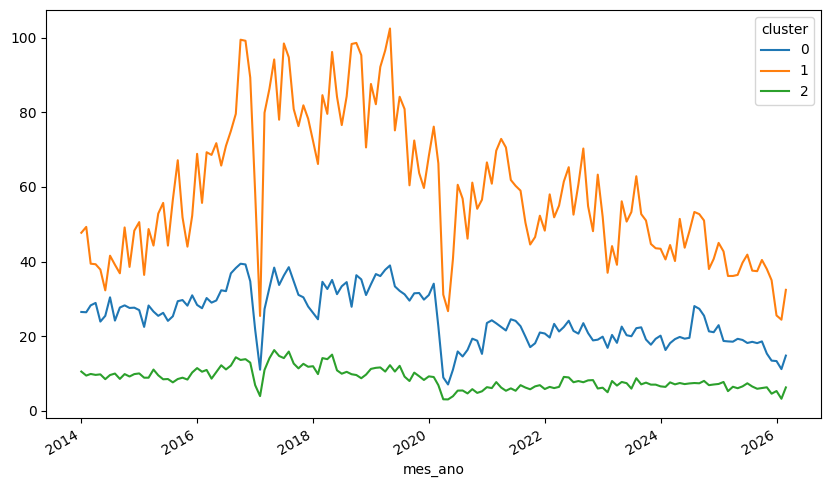

In [6]:
df["occur_onibus"] = df["roubo_em_coletivo"] + df["furto_coletivo"]

pivot = df.pivot_table(
    index="cisp",
    columns="mes_ano",
    values= "occur_onibus"
).fillna(0)
pivot_norm = sklearn.preprocessing.StandardScaler().fit_transform(pivot)
kmeans = sklearn.cluster.KMeans(n_clusters=3)
labels = kmeans.fit_predict(pivot_norm)

pivot['cluster'] = labels

pivot.groupby('cluster').mean().T.plot(figsize=(10,6))
plt.show()

In [8]:
pivot[pivot["cluster"]==1]

mes_ano,2014-01-01 00:00:00,2014-02-01 00:00:00,2014-03-01 00:00:00,2014-04-01 00:00:00,2014-05-01 00:00:00,2014-06-01 00:00:00,2014-07-01 00:00:00,2014-08-01 00:00:00,2014-09-01 00:00:00,2014-10-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,cluster
cisp,,,,,,,,,,,,,,,,,,,,,
16,41.0,54.0,52.0,44.0,52.0,27.0,53.0,69.0,45.0,47.0,...,60.0,64.0,34.0,68.0,59.0,49.0,39.0,52.0,56.0,1
17,71.0,66.0,38.0,42.0,42.0,33.0,47.0,39.0,32.0,38.0,...,21.0,23.0,21.0,21.0,29.0,16.0,19.0,14.0,15.0,1
21,69.0,72.0,64.0,48.0,51.0,36.0,42.0,46.0,49.0,68.0,...,38.0,58.0,66.0,70.0,86.0,81.0,43.0,36.0,44.0,1
29,23.0,41.0,31.0,44.0,27.0,28.0,38.0,24.0,31.0,35.0,...,66.0,33.0,53.0,39.0,33.0,48.0,21.0,26.0,47.0,1
32,52.0,42.0,33.0,45.0,27.0,25.0,48.0,40.0,52.0,95.0,...,63.0,53.0,60.0,51.0,46.0,24.0,30.0,27.0,37.0,1
59,56.0,45.0,29.0,31.0,31.0,40.0,37.0,31.0,28.0,38.0,...,17.0,13.0,16.0,11.0,7.0,10.0,10.0,3.0,5.0,1
64,22.0,25.0,29.0,21.0,35.0,37.0,26.0,25.0,21.0,23.0,...,28.0,19.0,12.0,23.0,6.0,17.0,17.0,13.0,23.0,1


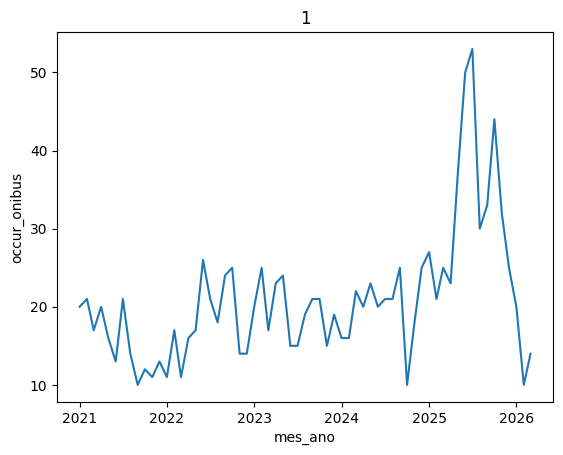

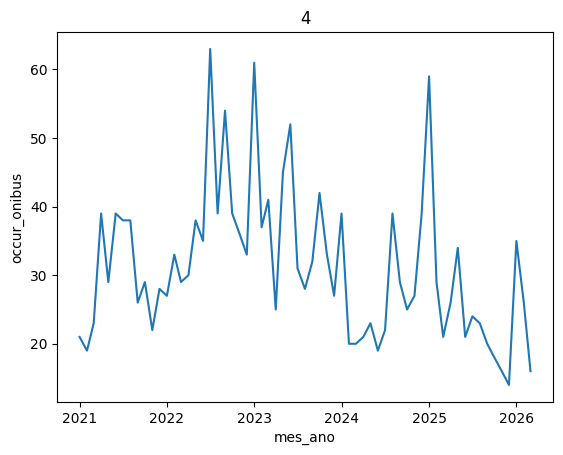

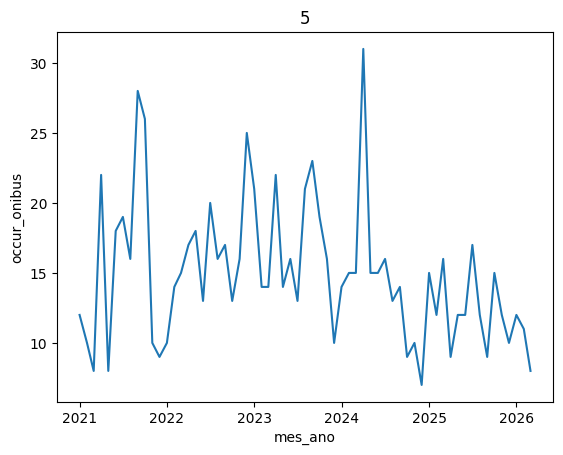

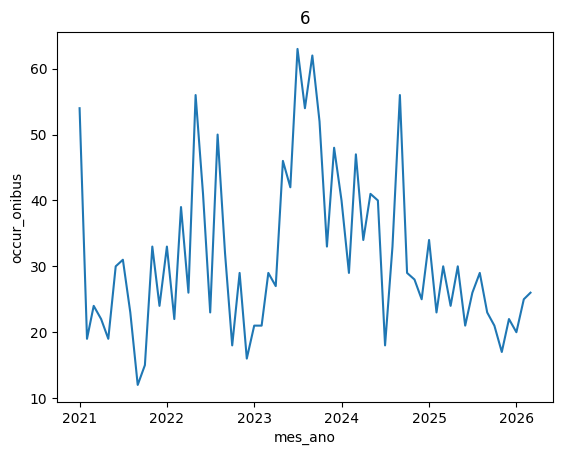

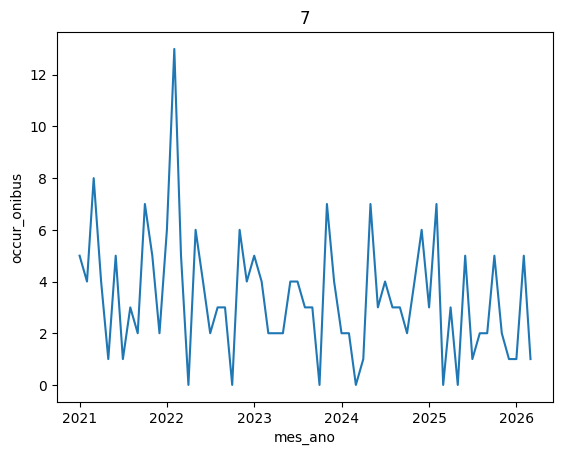

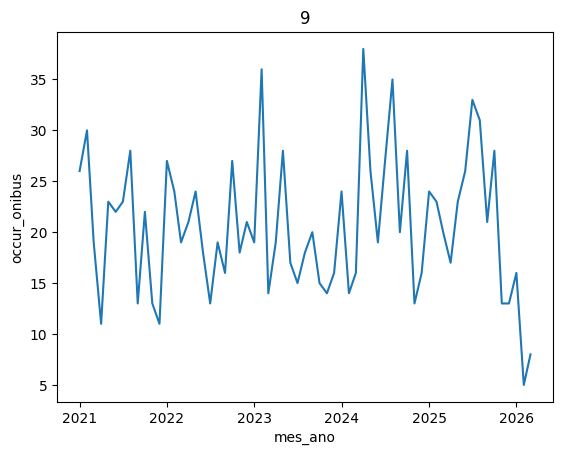

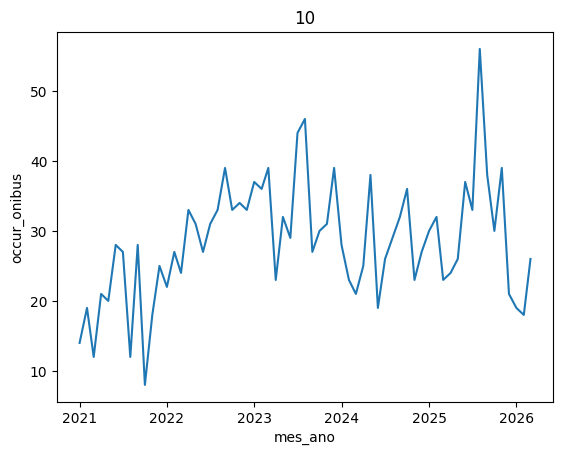

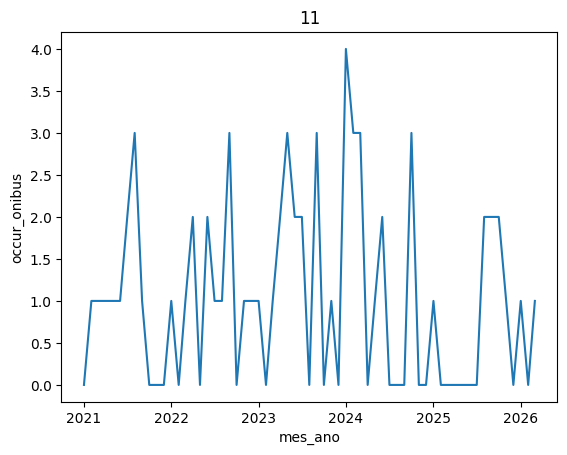

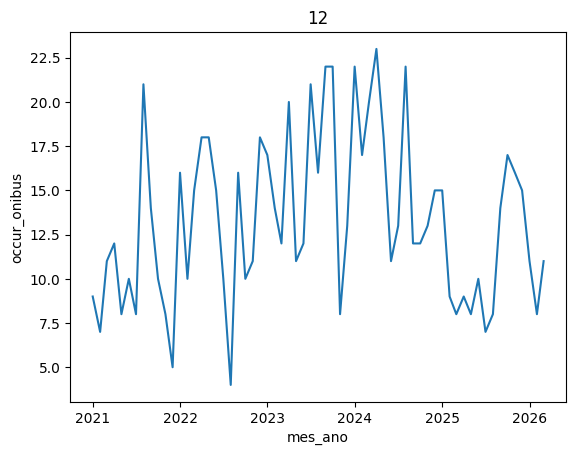

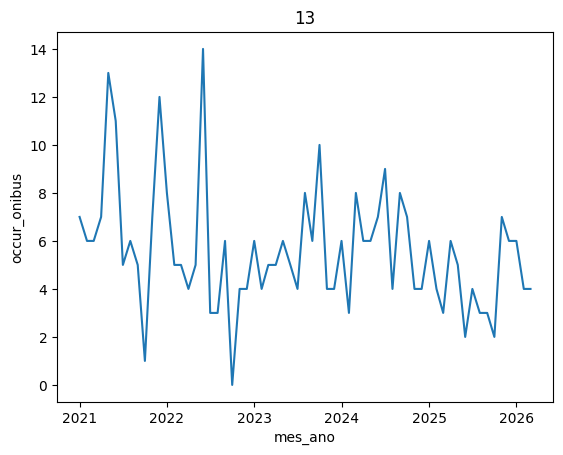

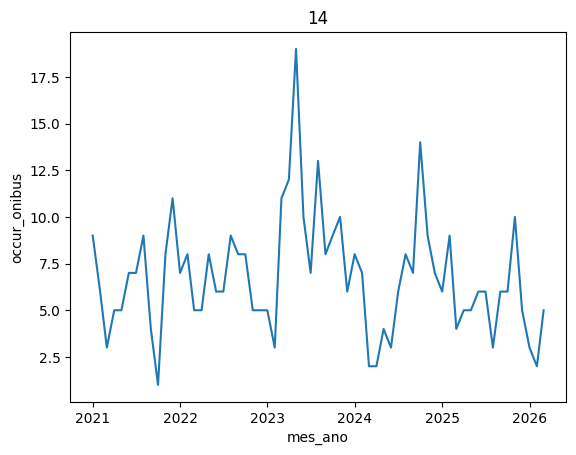

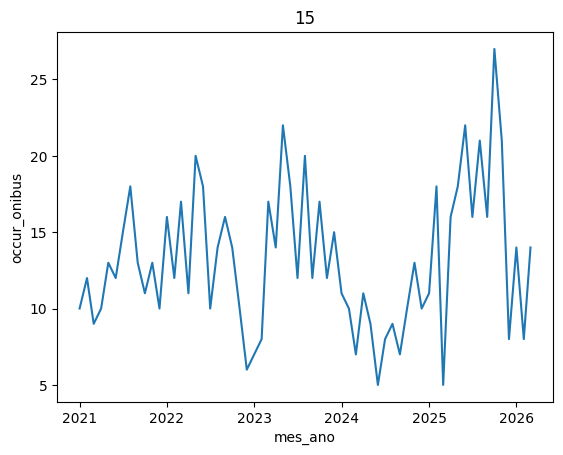

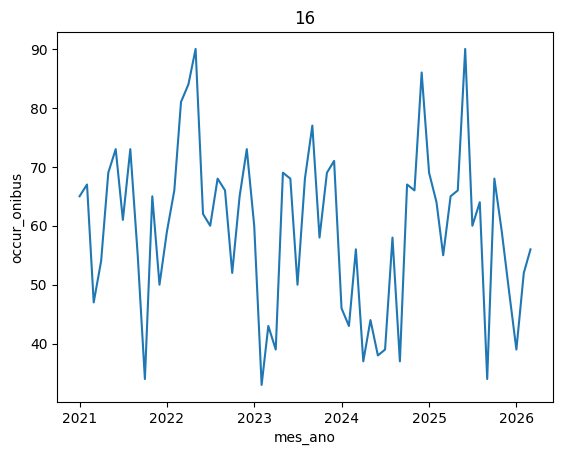

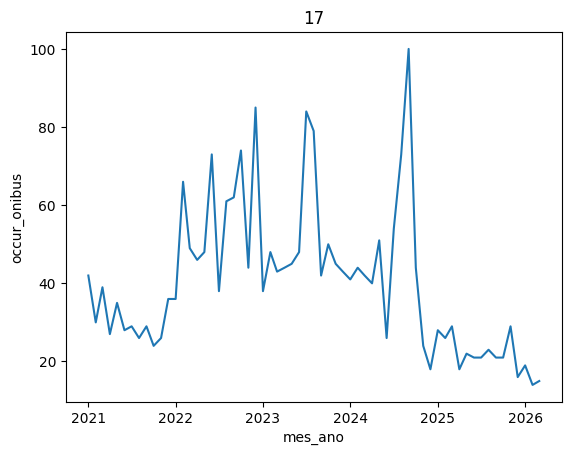

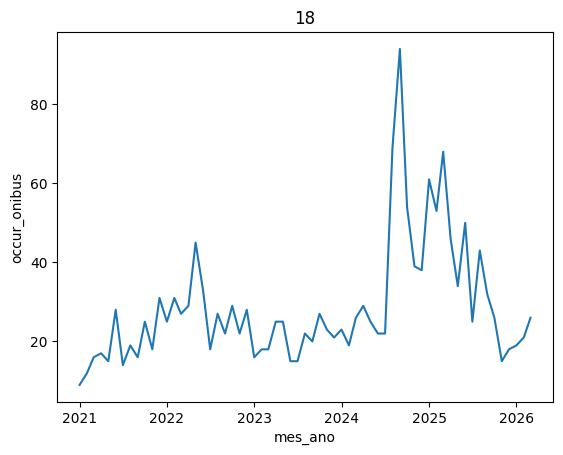

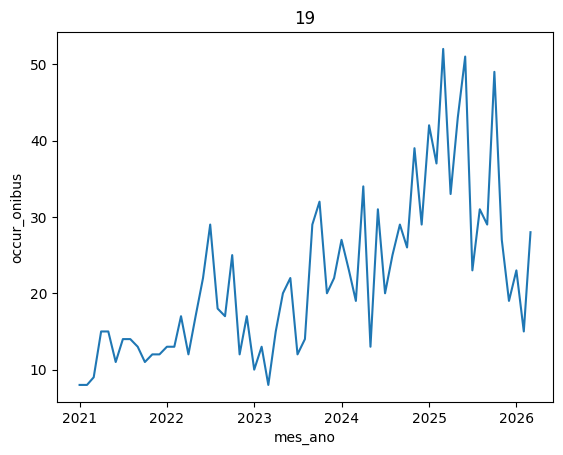

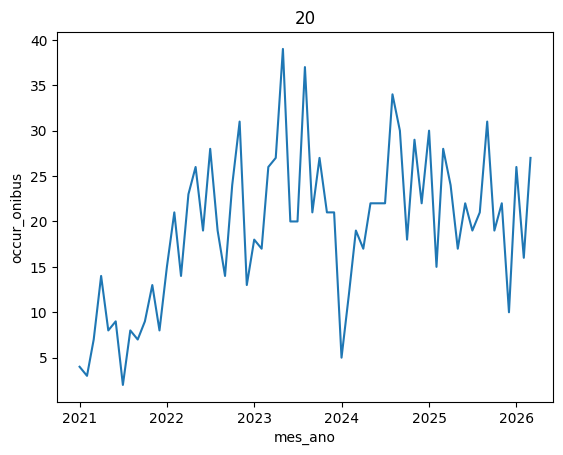

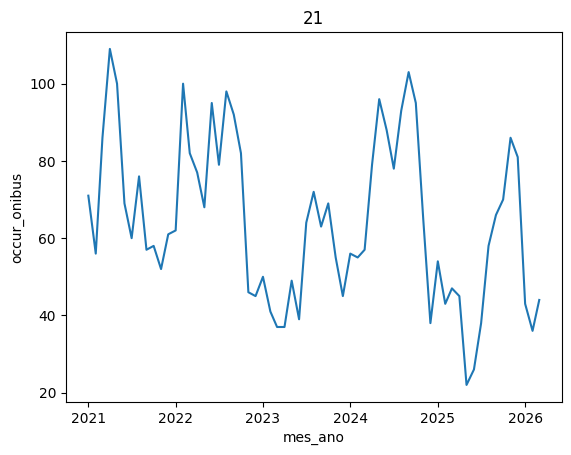

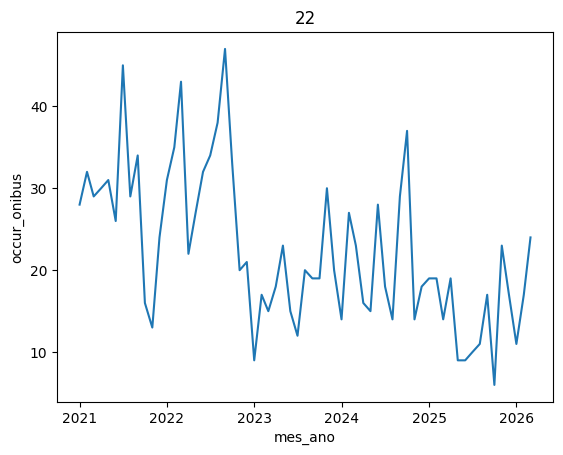

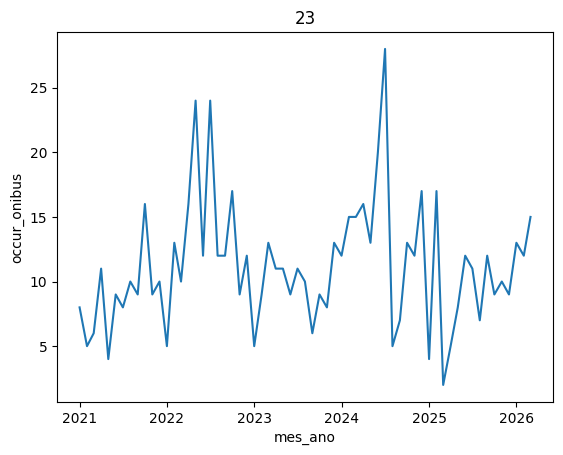

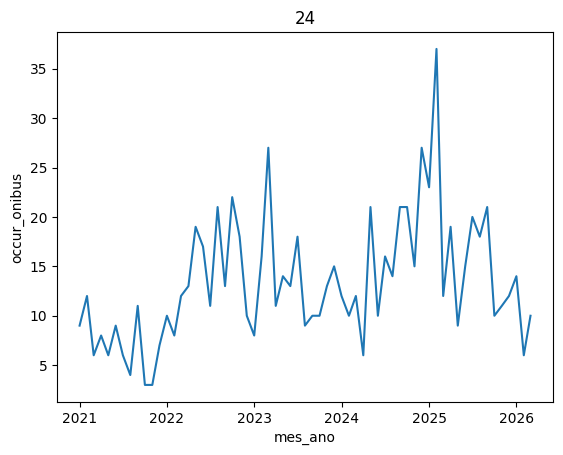

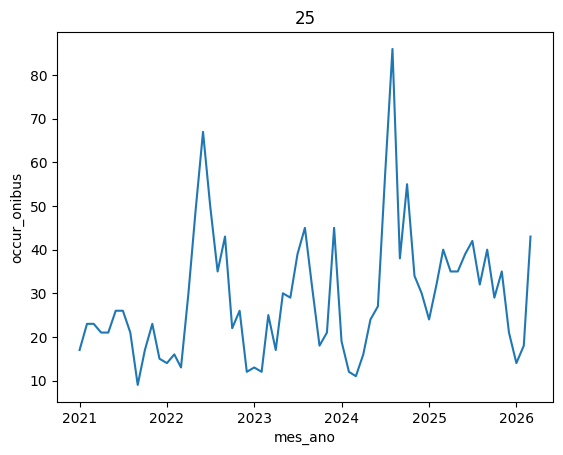

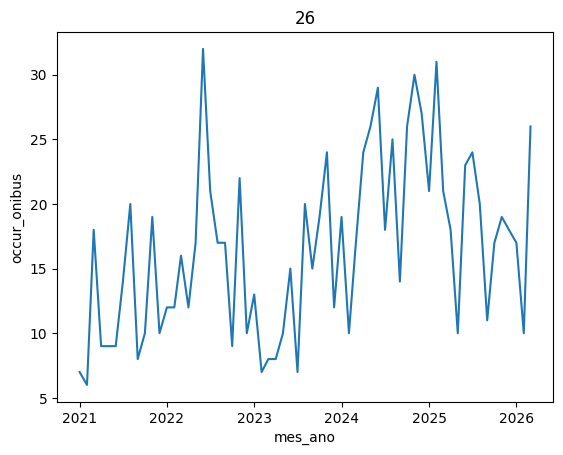

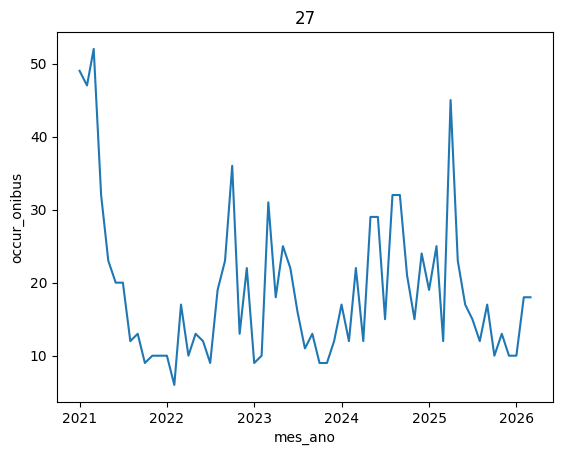

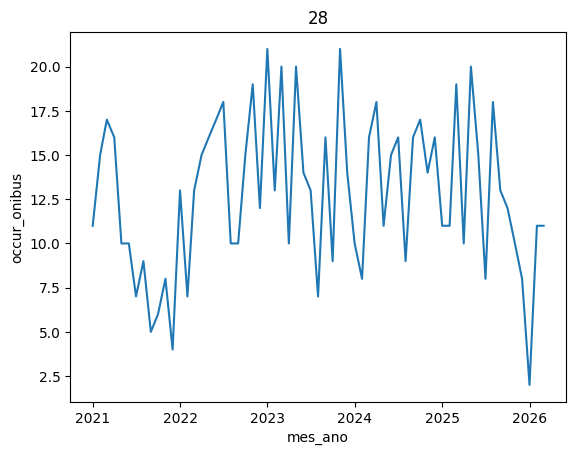

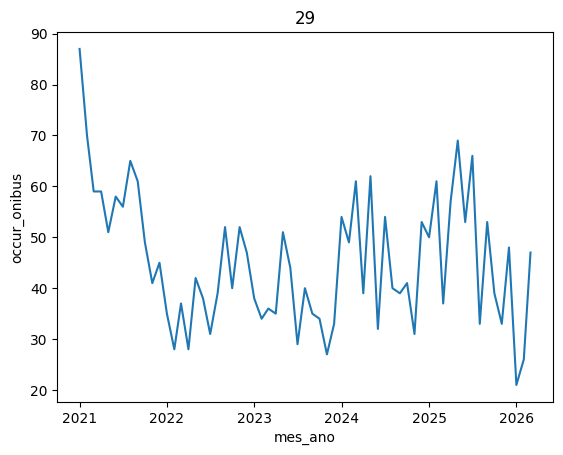

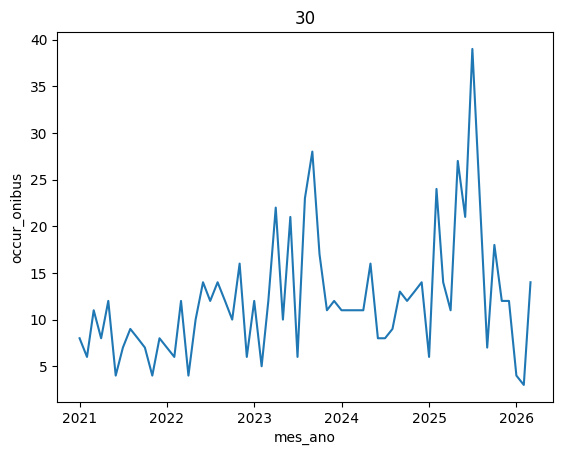

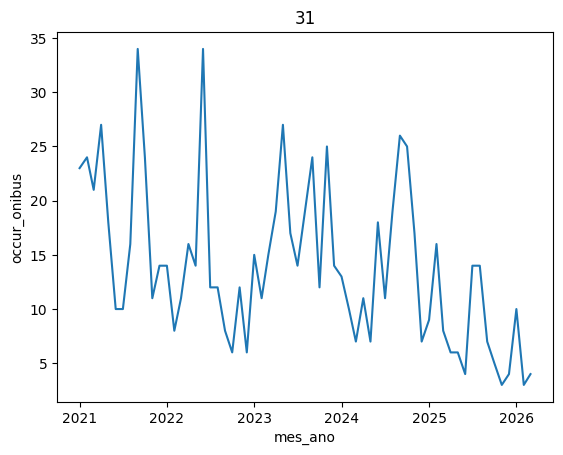

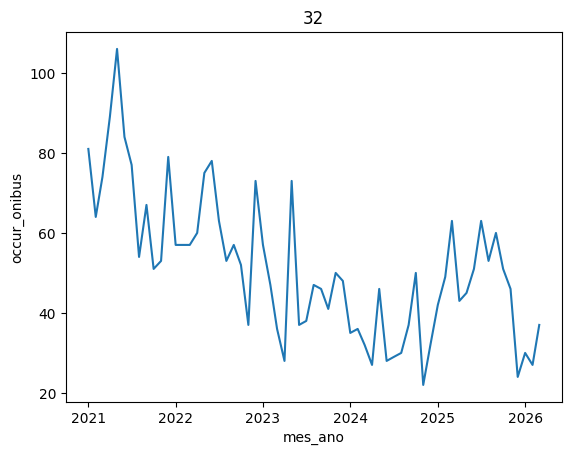

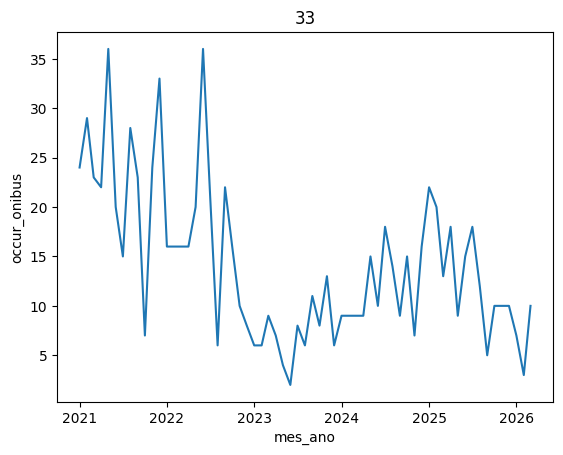

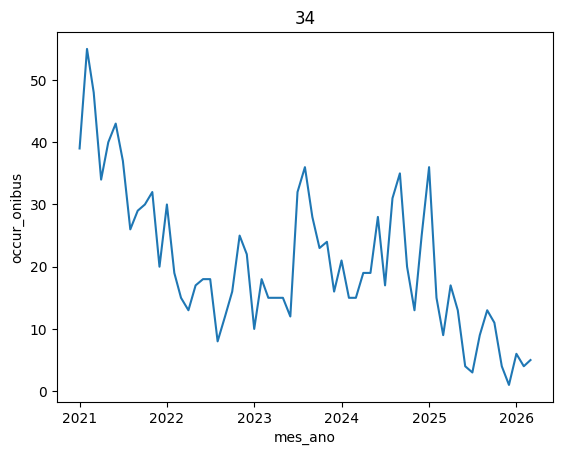

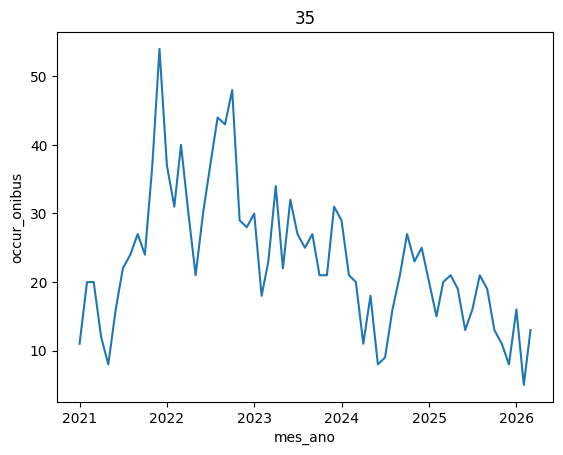

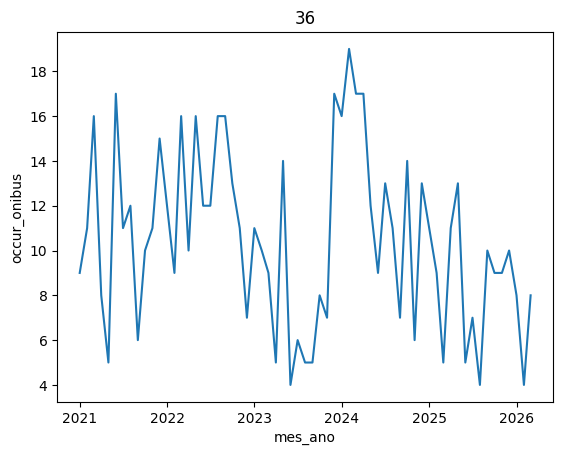

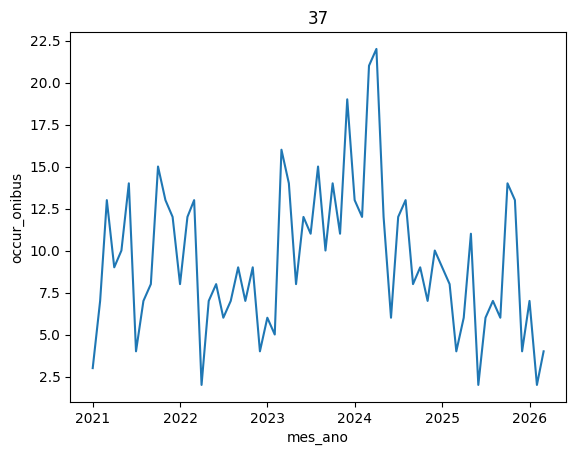

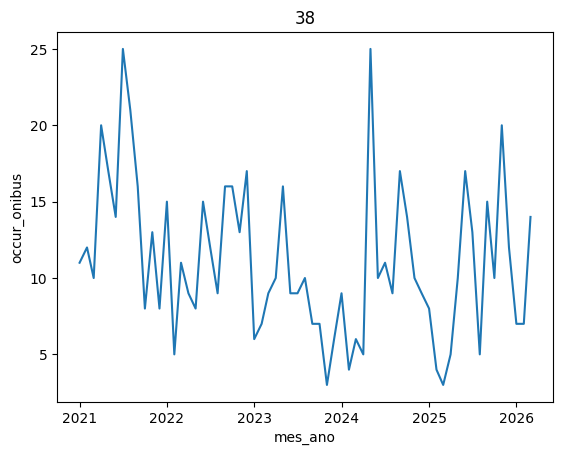

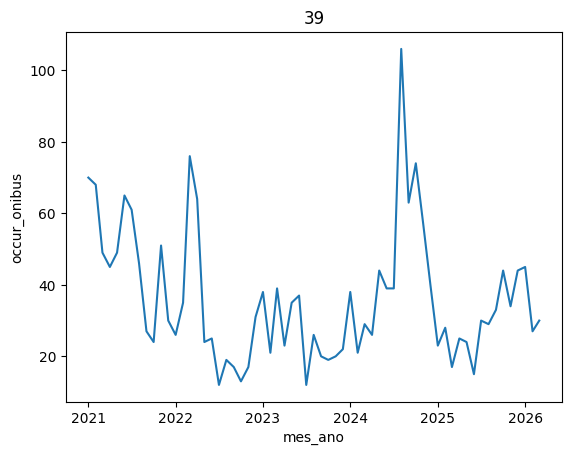

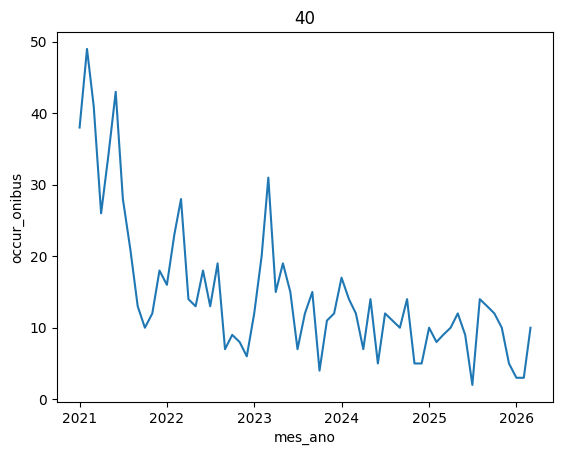

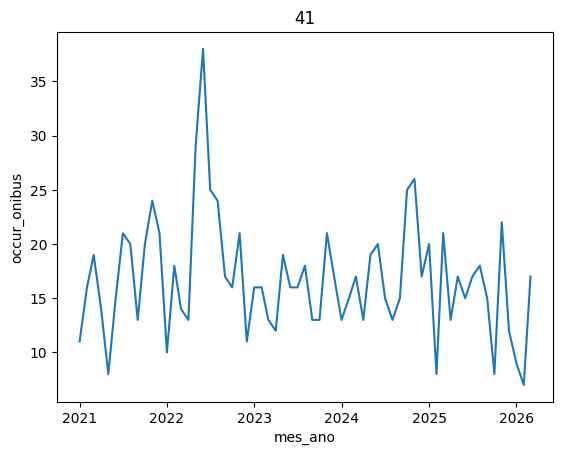

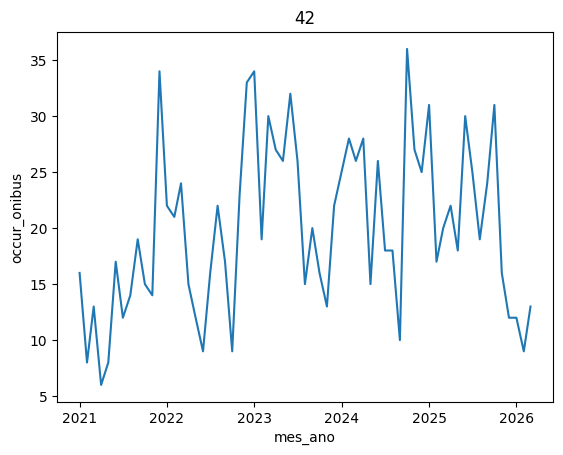

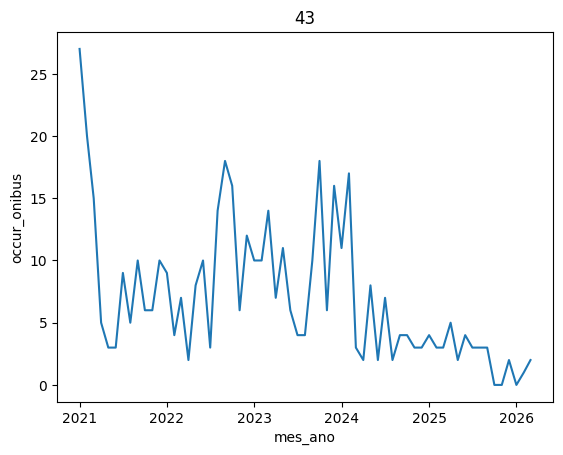

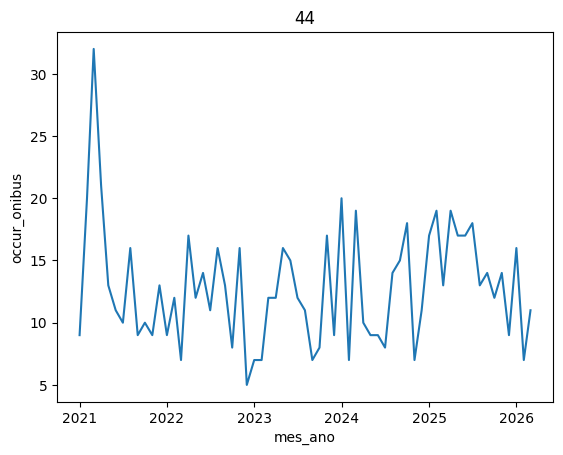

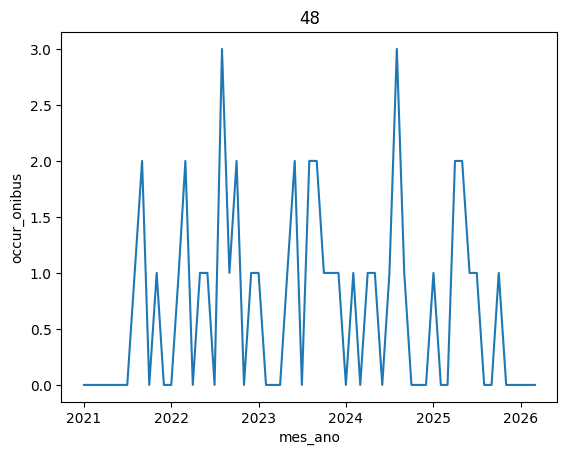

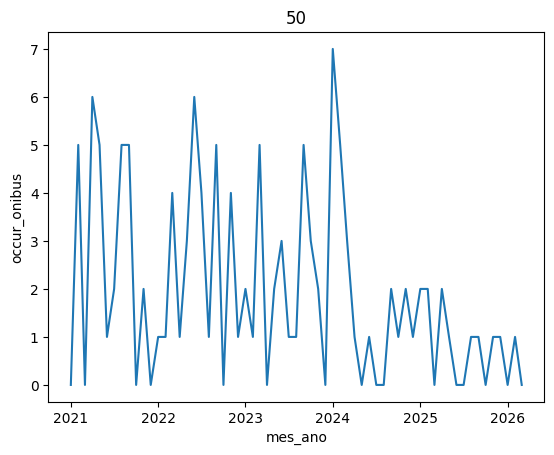

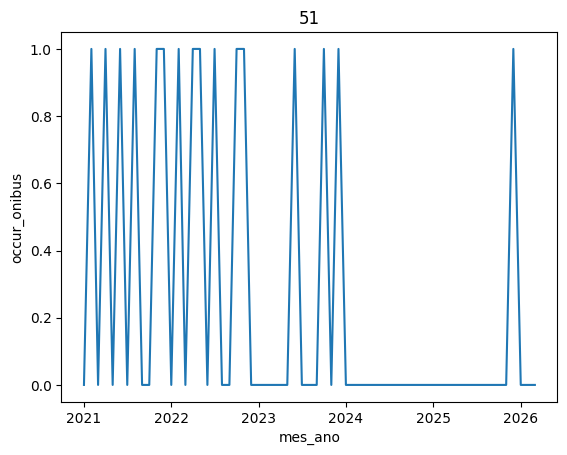

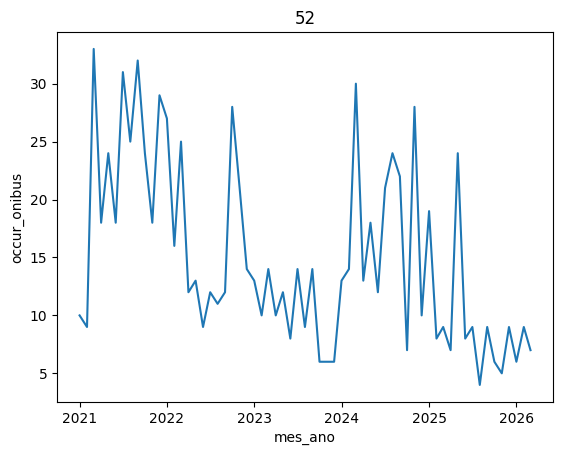

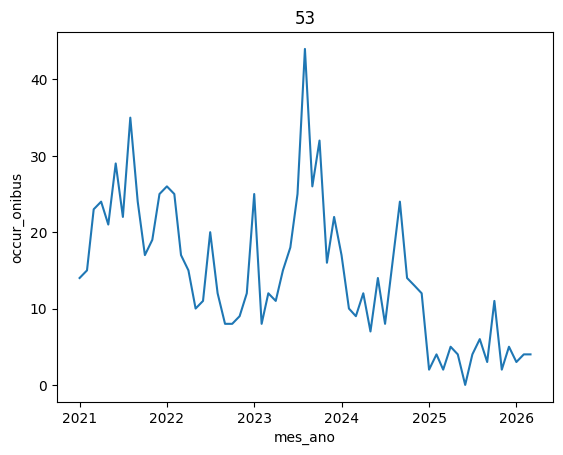

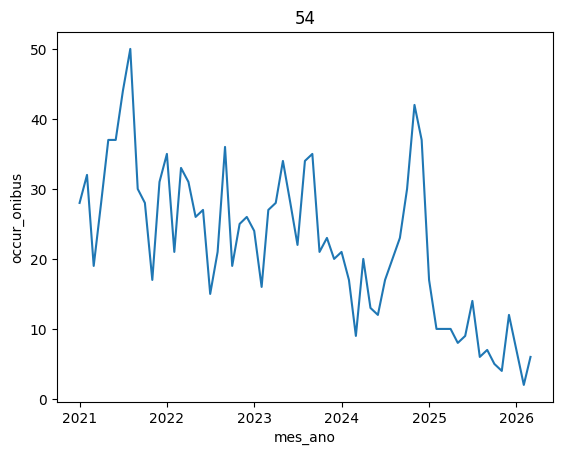

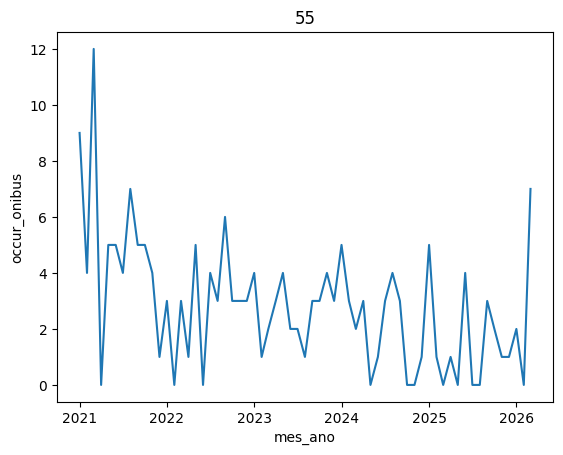

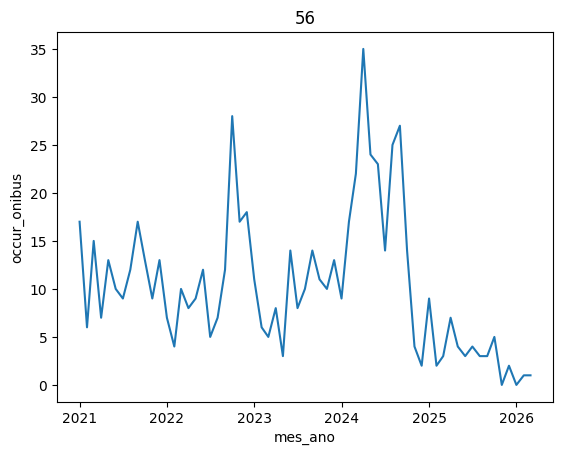

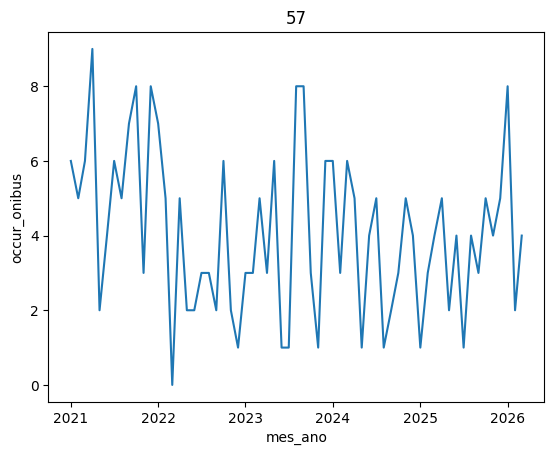

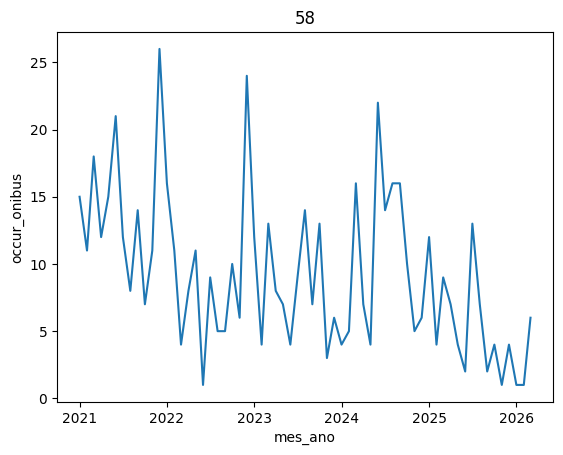

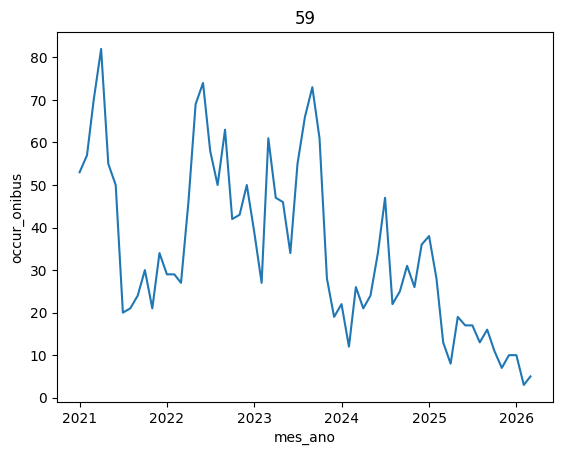

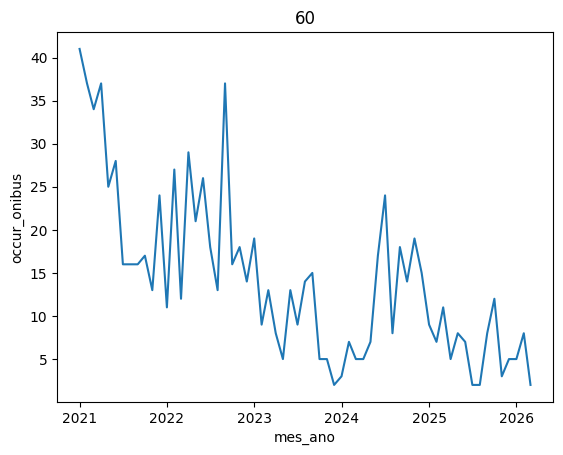

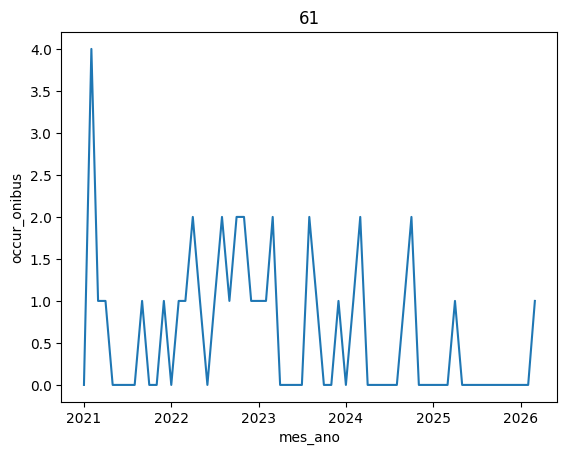

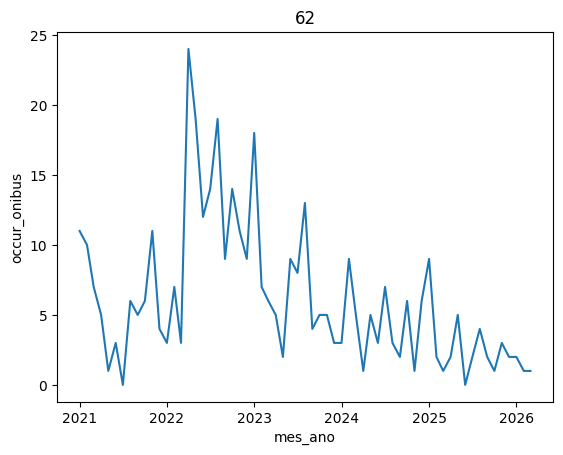

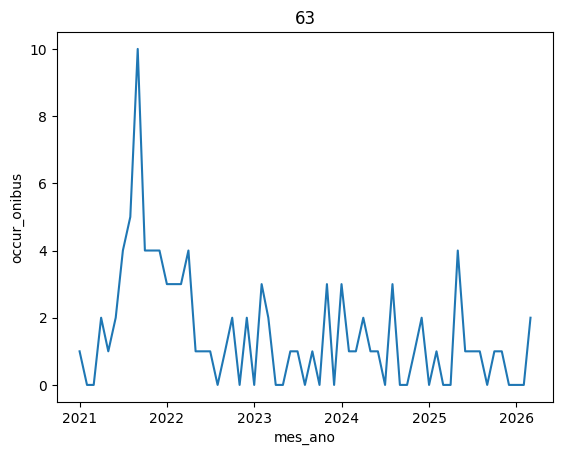

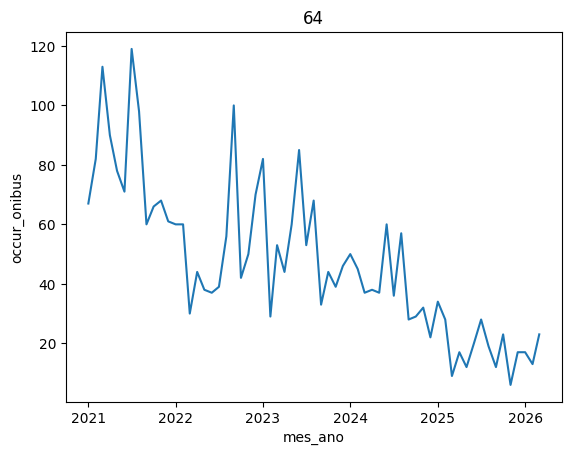

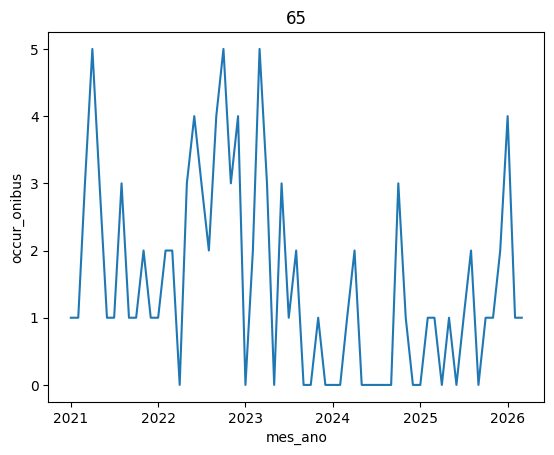

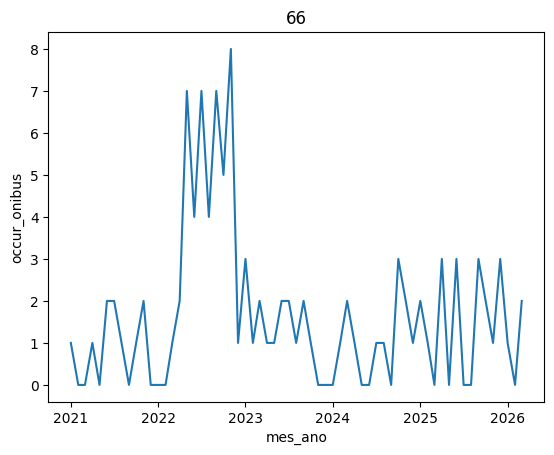

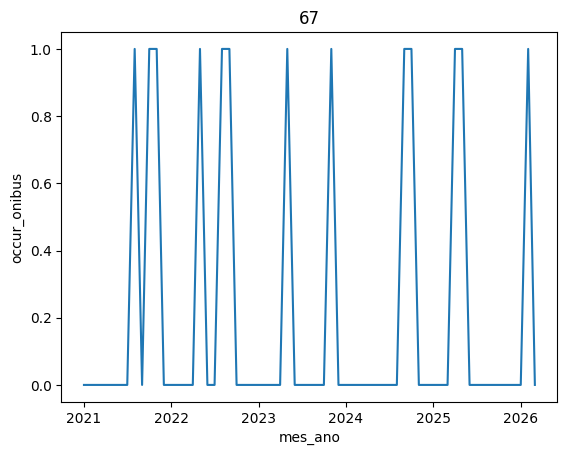

In [9]:
#e se eu pegar de 2024 pra ca?
df_rec = df[df["ano"]>=2021]
l=[]
cisps = df_rec["cisp"].unique()
for cisp in cisps:
    df_temp = df_rec[ df_rec["cisp"] == cisp]
    df_part = df_temp[["mes_ano","occur_onibus"]]
    sns.lineplot(data=df_part, x="mes_ano",y="occur_onibus")
    plt.title(cisp)
    plt.show()
    x = np.arange(len(df_part["mes_ano"]))
    coefs = np.polyfit(x, df_part["occur_onibus"], 1)
    if coefs[0] > 0:
        l.append((coefs[0],cisp))

In [10]:
l=sorted(l)
l

[(np.float64(0.00014400921658986633), np.int64(48)),
 (np.float64(0.015216973886328877), np.int64(28)),
 (np.float64(0.018769201228878745), np.int64(12)),
 (np.float64(0.0205453149001538), np.int64(23)),
 (np.float64(0.028993855606758913), np.int64(15)),
 (np.float64(0.09499807987711227), np.int64(42)),
 (np.float64(0.1310963901689709), np.int64(30)),
 (np.float64(0.13157642089093713), np.int64(24)),
 (np.float64(0.14007296466973918), np.int64(10)),
 (np.float64(0.16551459293394788), np.int64(26)),
 (np.float64(0.22182219662058422), np.int64(25)),
 (np.float64(0.22287826420890952), np.int64(20)),
 (np.float64(0.23103878648233506), np.int64(1)),
 (np.float64(0.33520545314900163), np.int64(18)),
 (np.float64(0.4073060675883257), np.int64(19))]

Inércia final: 415484.2435435435


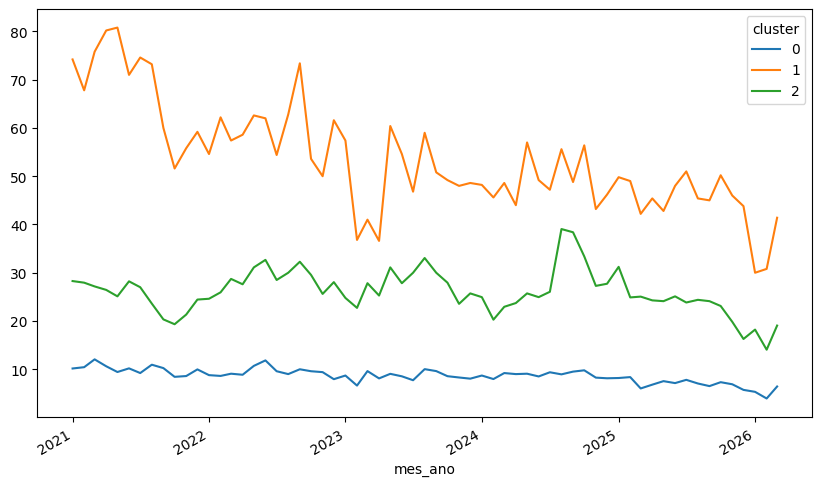

In [11]:
pivot = df_rec.pivot_table(
    index="cisp",
    columns="mes_ano",
    values= "occur_onibus"
).fillna(0)
pivot_norm = sklearn.preprocessing.StandardScaler().fit_transform(pivot)
kmeans = sklearn.cluster.KMeans(n_clusters=3, random_state=1000)

labels = kmeans.fit_predict(pivot)
print(f"Inércia final: {kmeans.inertia_}")
pivot['cluster'] = labels

pivot.groupby('cluster').mean().T.plot(figsize=(10,6))
plt.show()

In [12]:
pivot[pivot["cluster"]==1]

mes_ano,2021-01-01 00:00:00,2021-02-01 00:00:00,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,cluster
cisp,,,,,,,,,,,,,,,,,,,,,
16,65.0,67.0,47.0,54.0,69.0,73.0,61.0,73.0,55.0,34.0,...,60.0,64.0,34.0,68.0,59.0,49.0,39.0,52.0,56.0,1
21,71.0,56.0,86.0,109.0,100.0,69.0,60.0,76.0,57.0,58.0,...,38.0,58.0,66.0,70.0,86.0,81.0,43.0,36.0,44.0,1
29,87.0,70.0,59.0,59.0,51.0,58.0,56.0,65.0,61.0,49.0,...,66.0,33.0,53.0,39.0,33.0,48.0,21.0,26.0,47.0,1
32,81.0,64.0,74.0,89.0,106.0,84.0,77.0,54.0,67.0,51.0,...,63.0,53.0,60.0,51.0,46.0,24.0,30.0,27.0,37.0,1
64,67.0,82.0,113.0,90.0,78.0,71.0,119.0,98.0,60.0,66.0,...,28.0,19.0,12.0,23.0,6.0,17.0,17.0,13.0,23.0,1


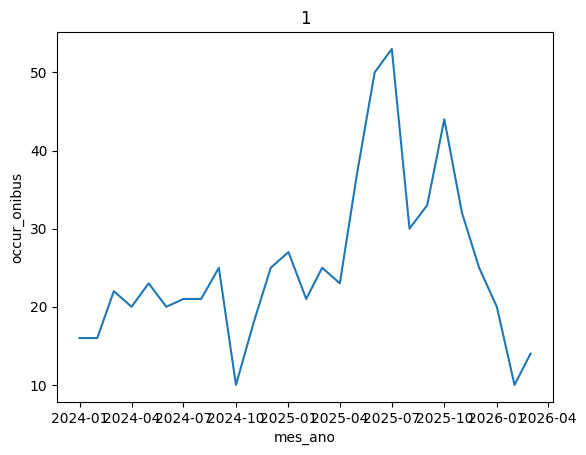

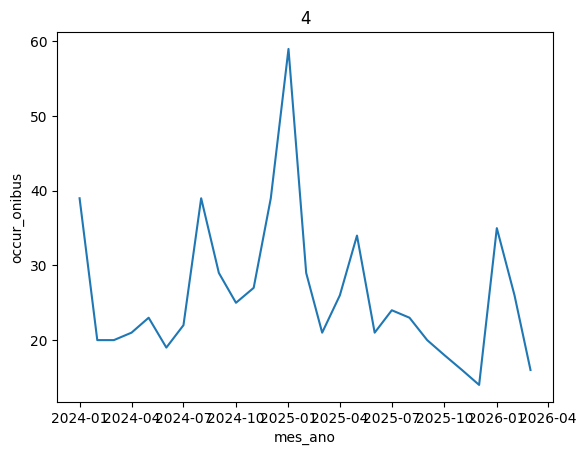

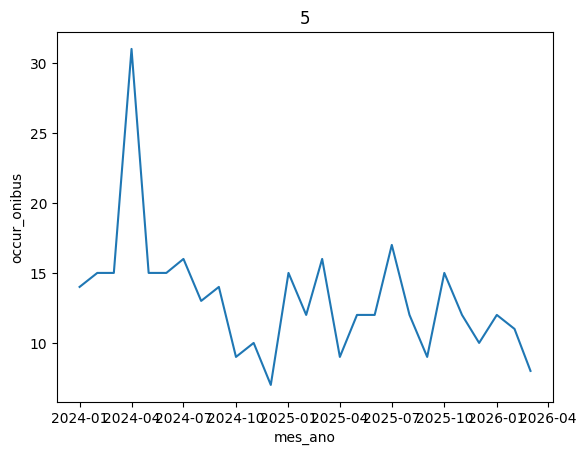

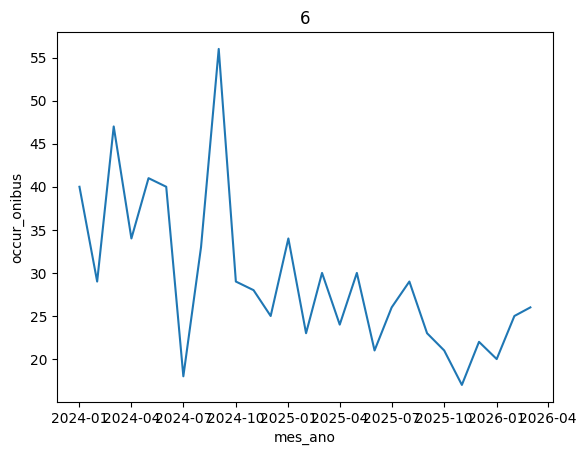

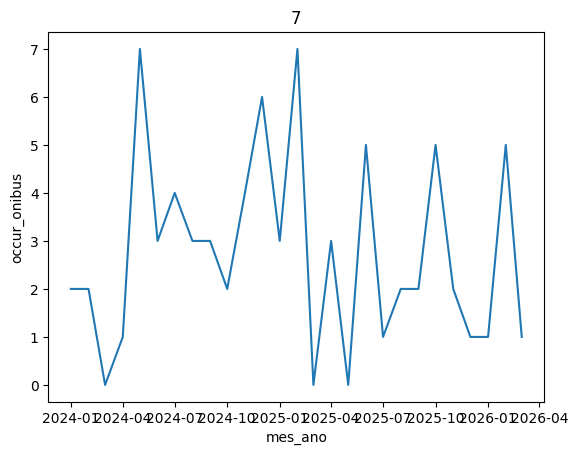

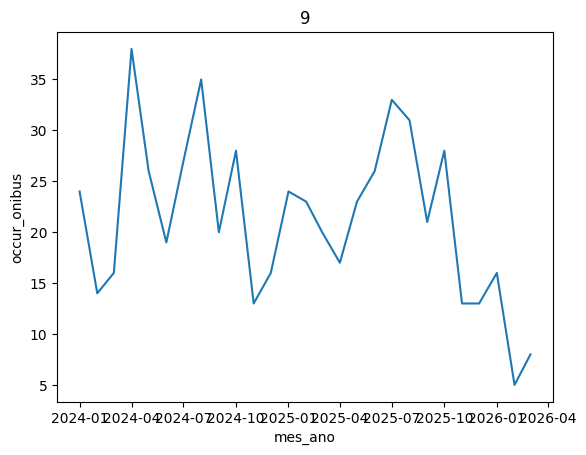

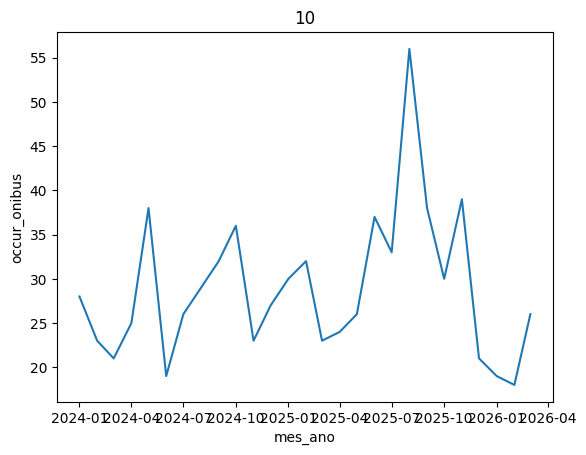

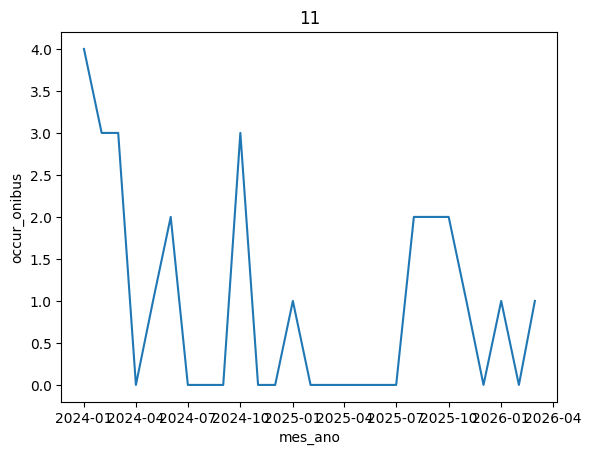

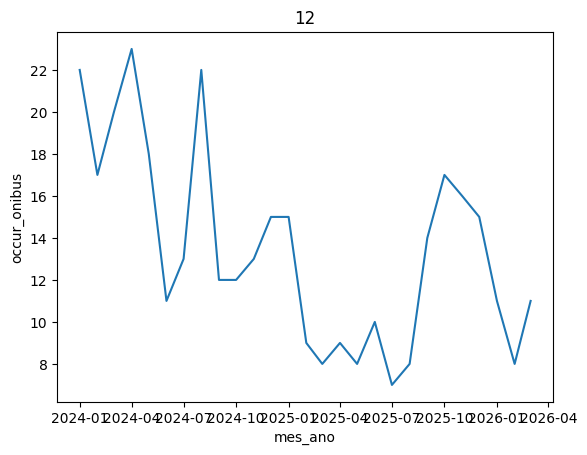

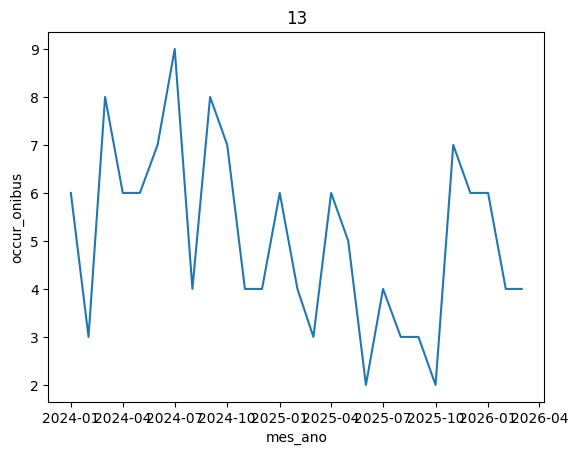

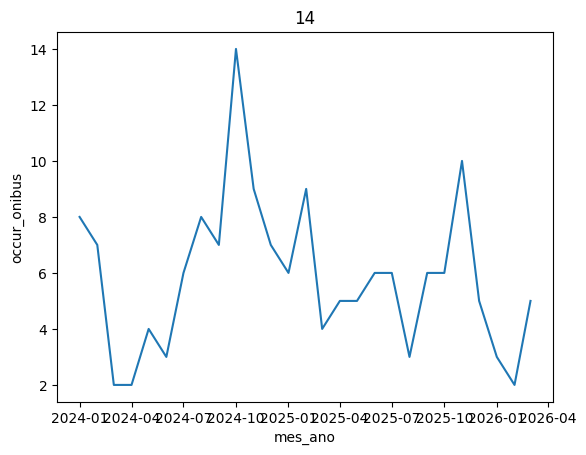

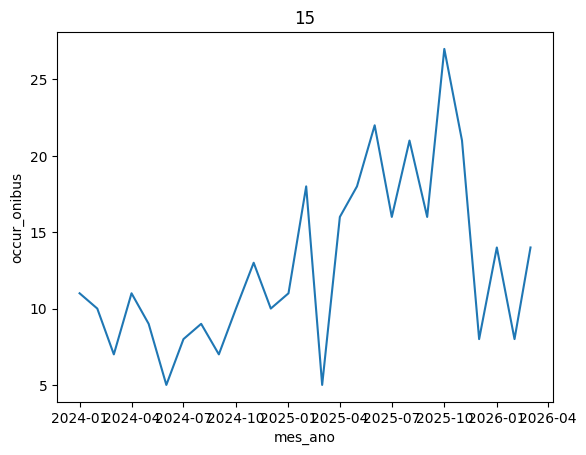

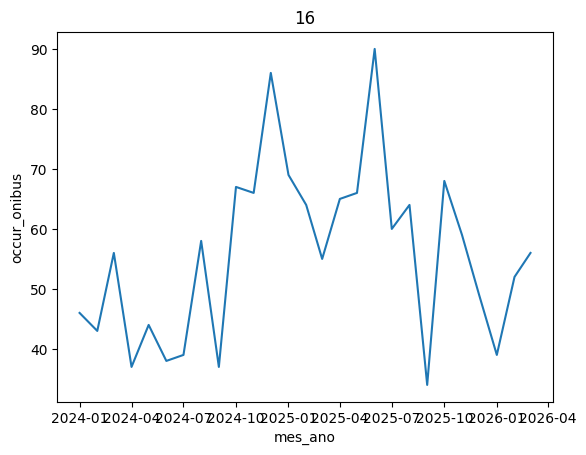

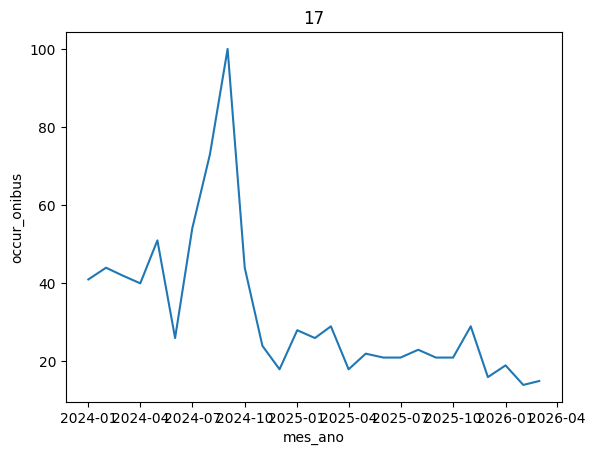

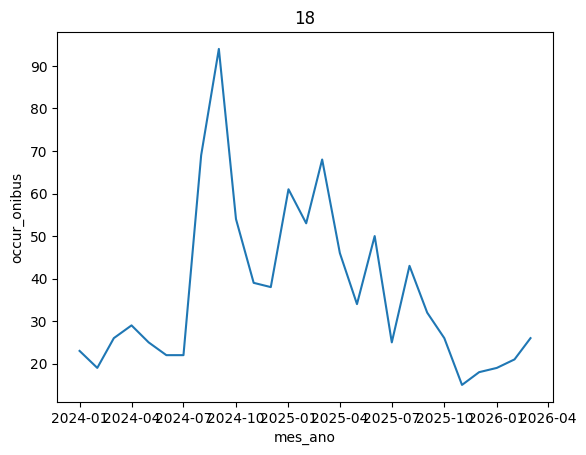

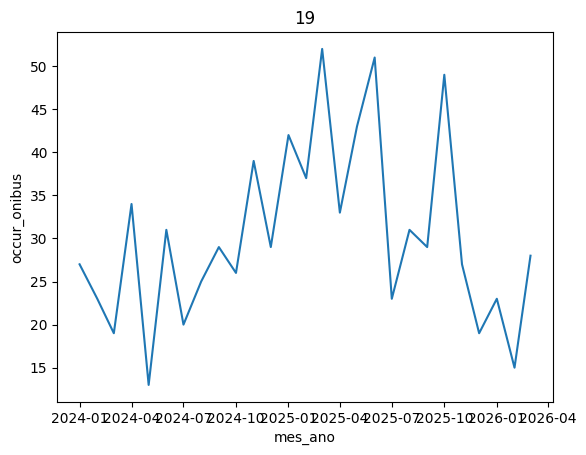

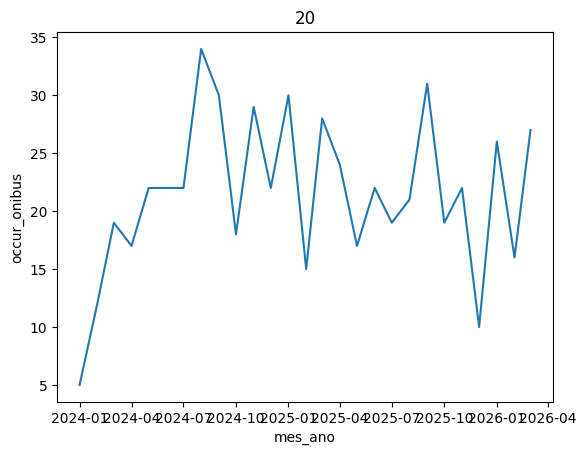

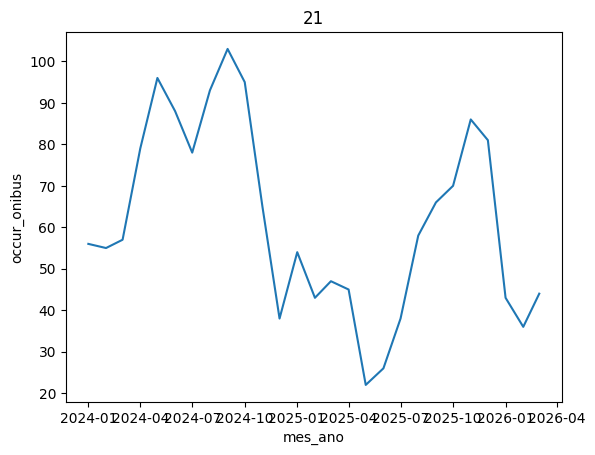

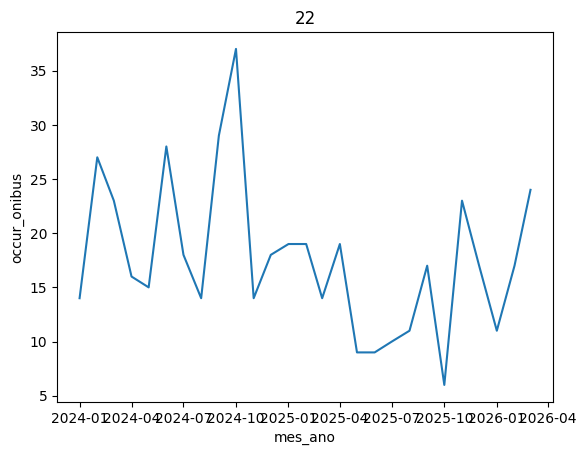

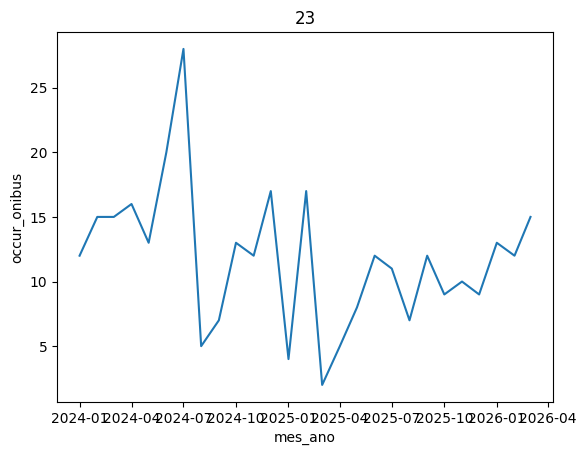

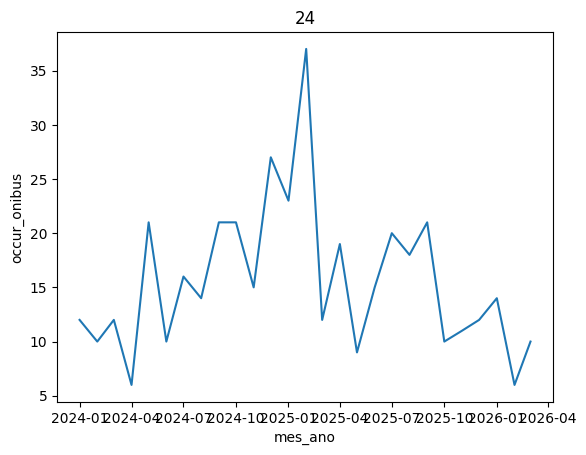

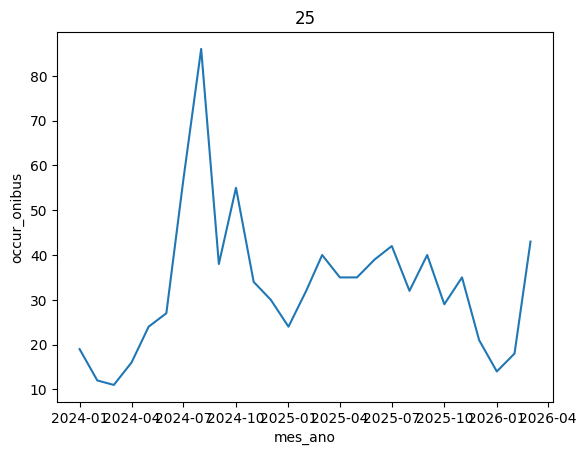

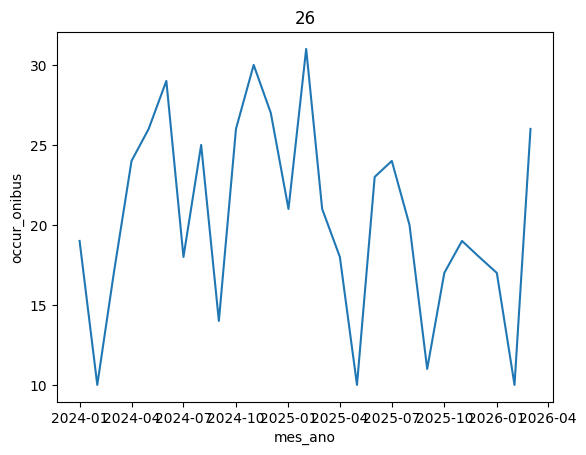

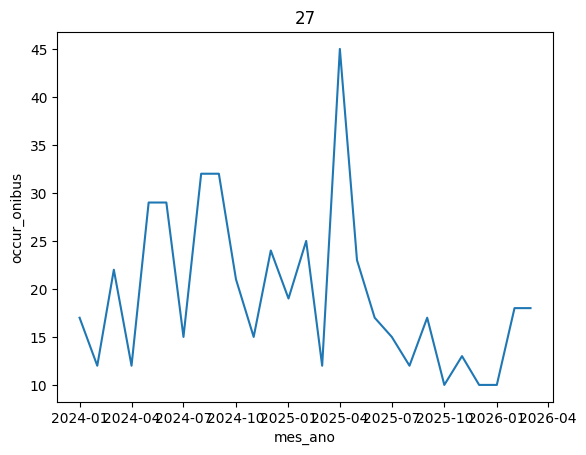

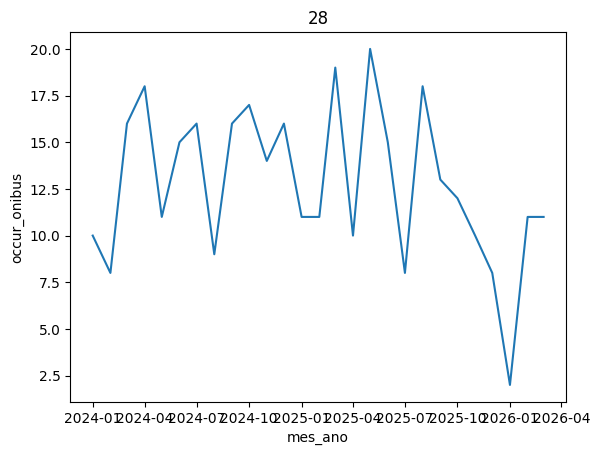

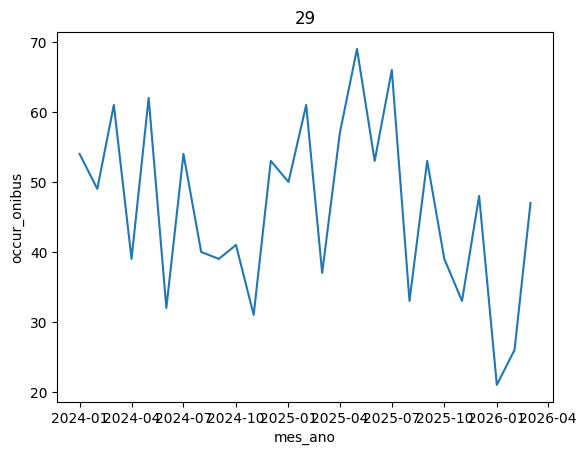

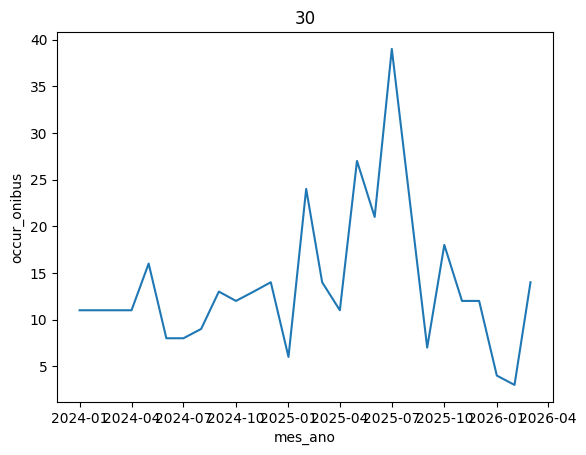

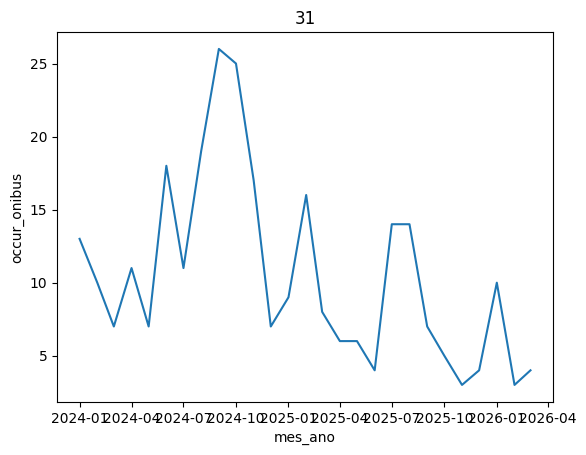

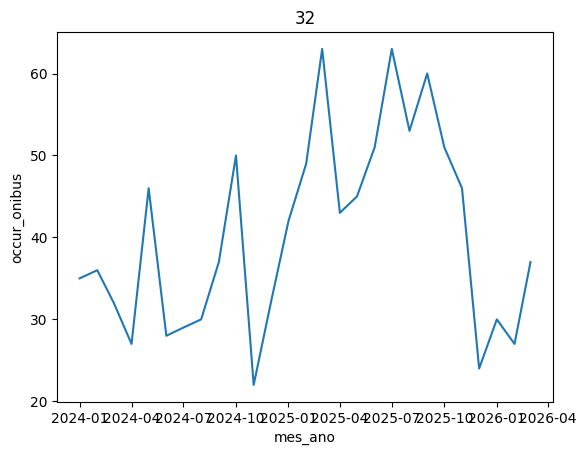

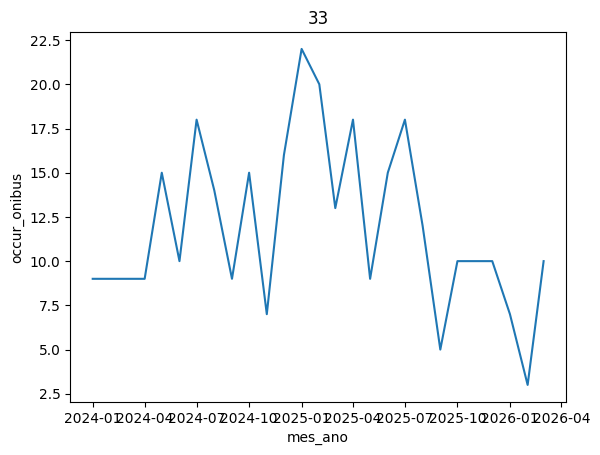

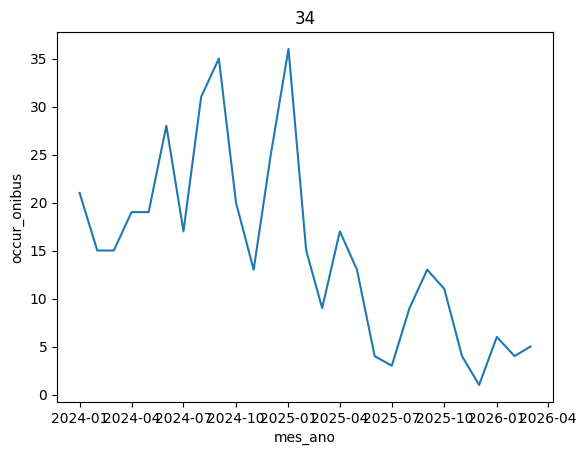

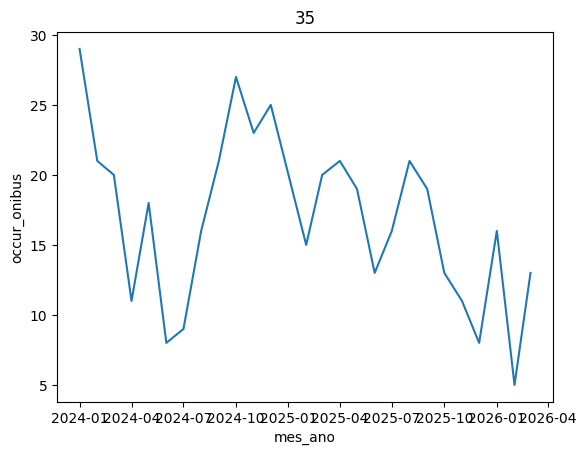

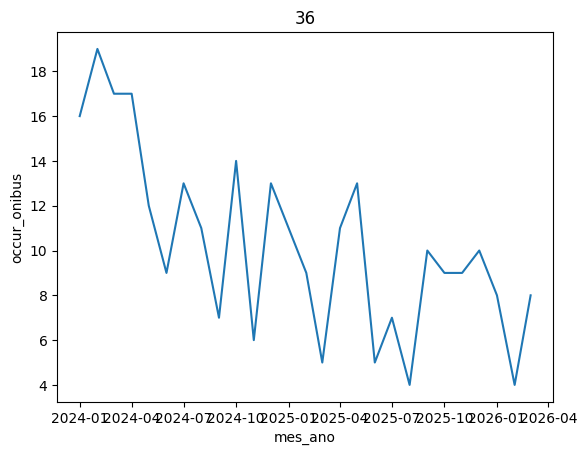

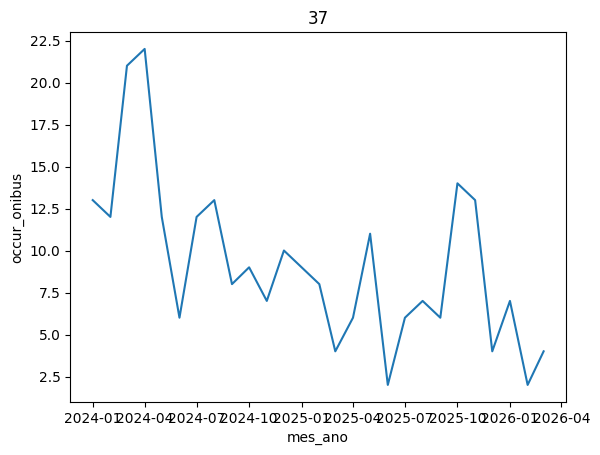

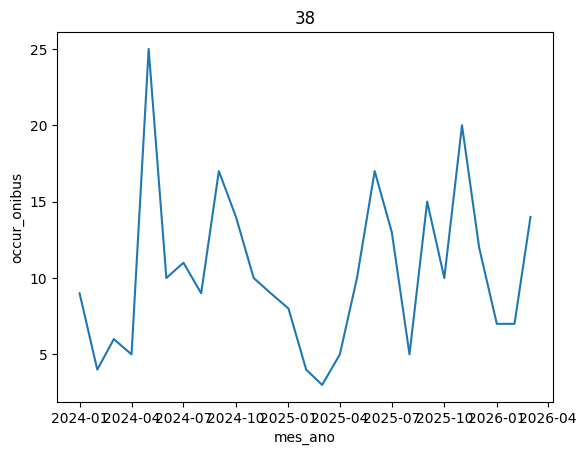

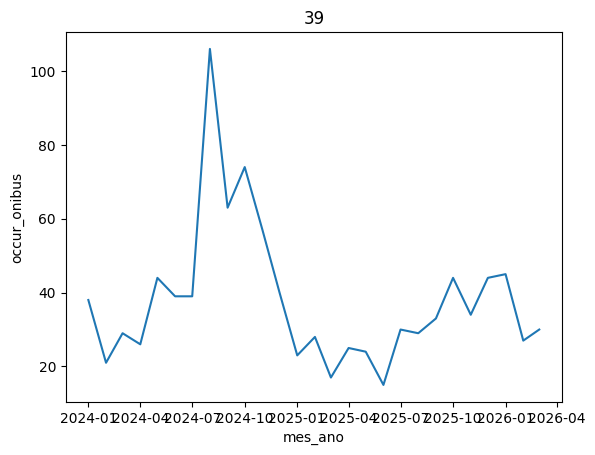

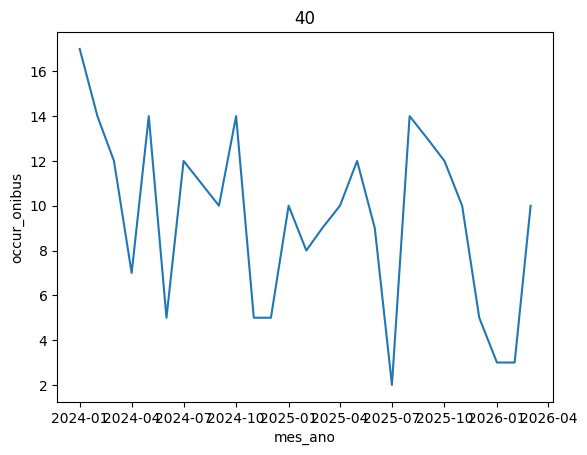

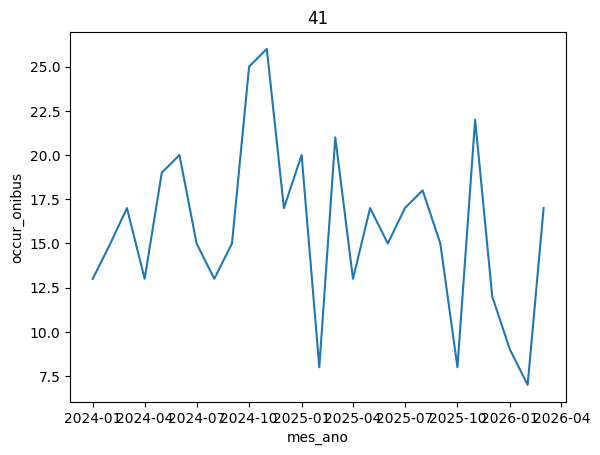

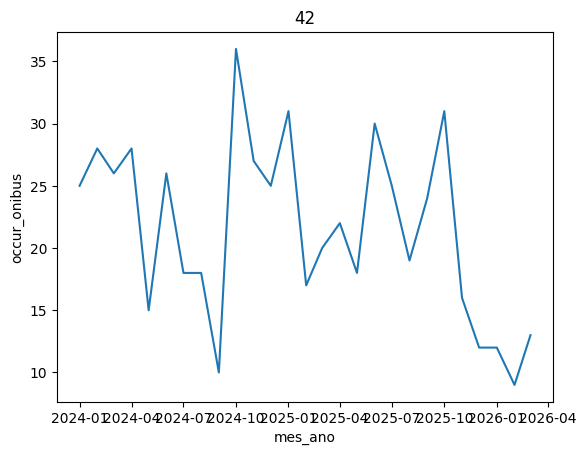

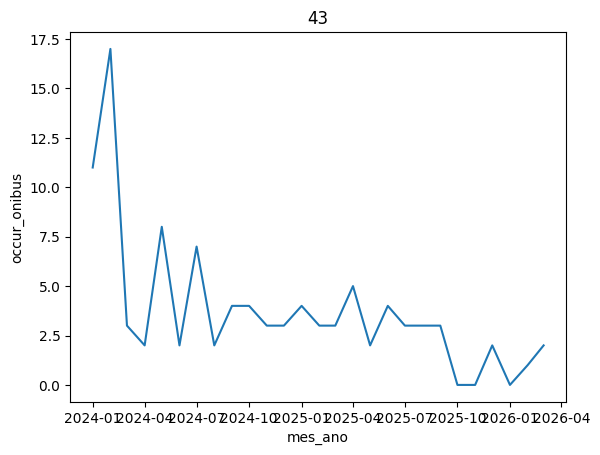

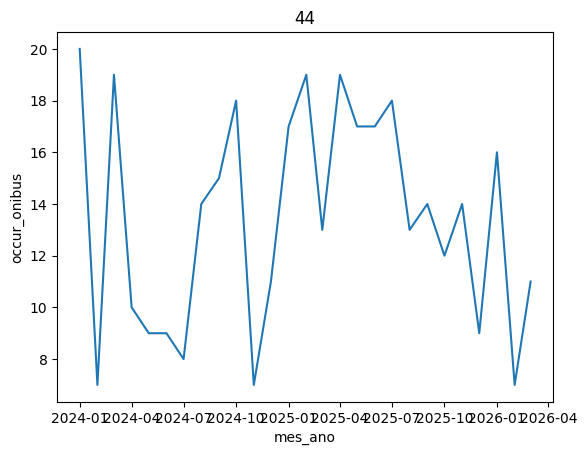

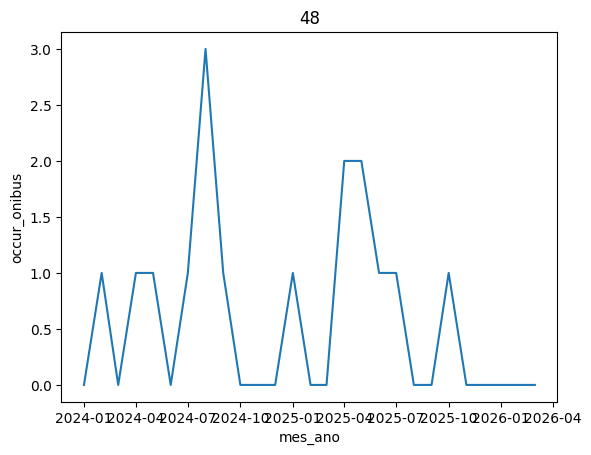

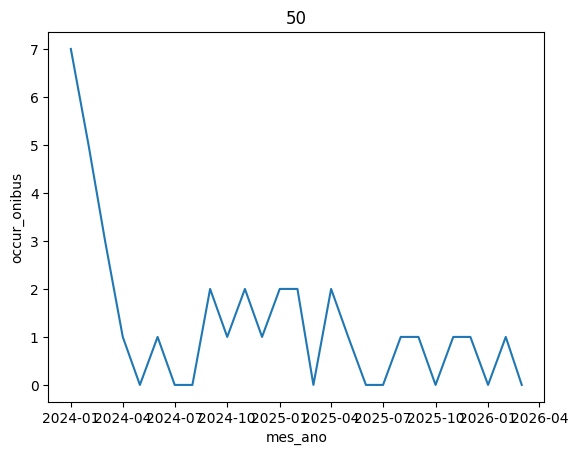

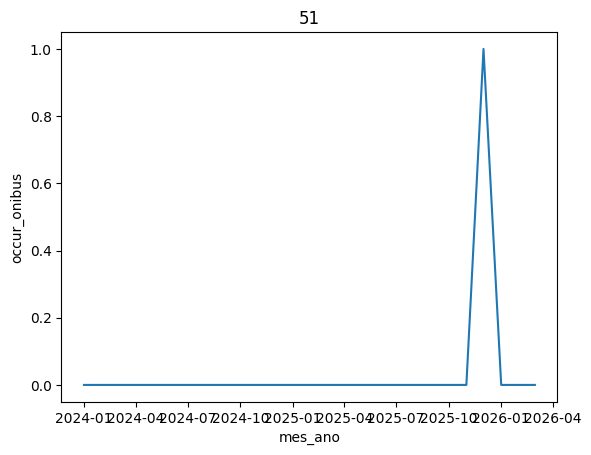

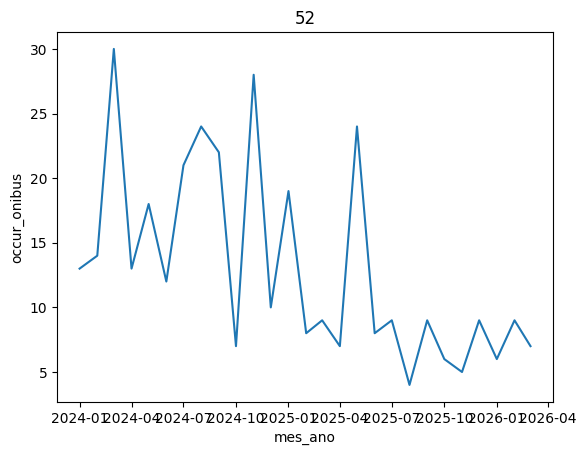

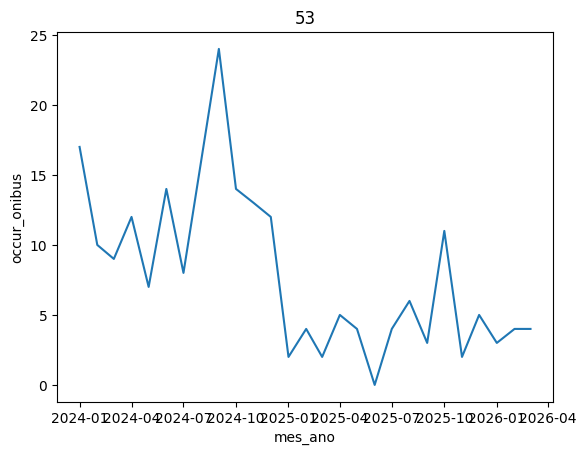

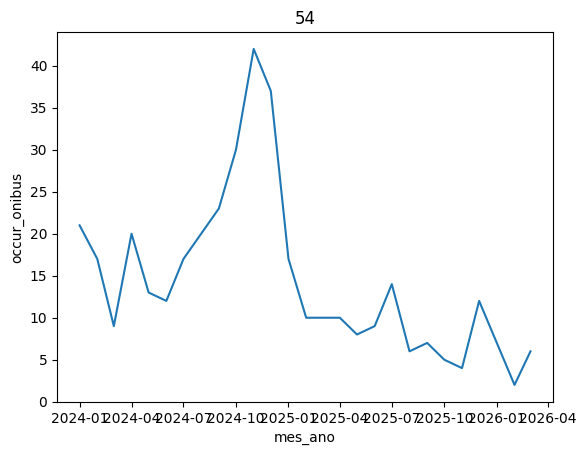

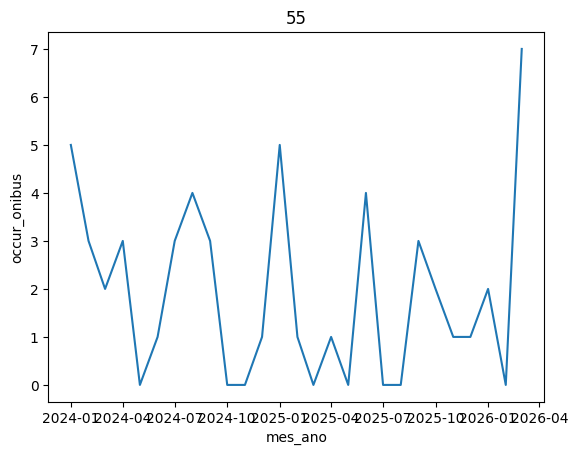

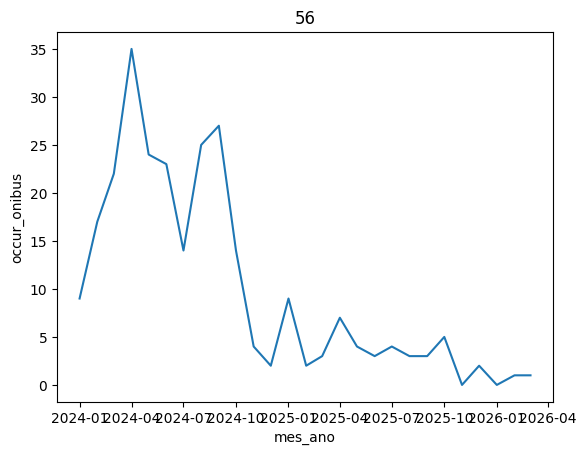

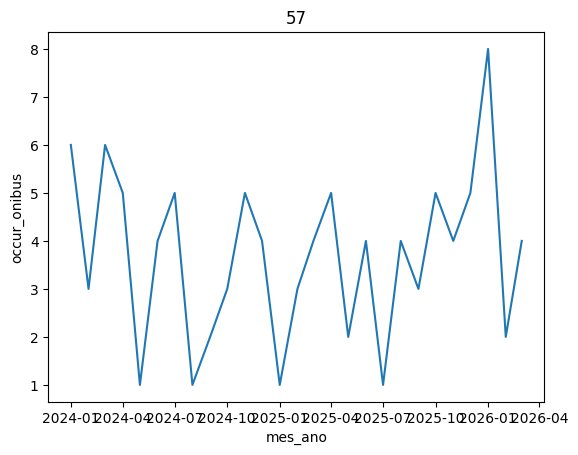

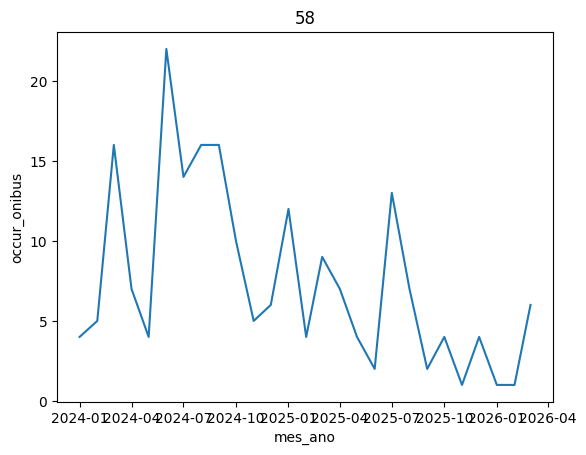

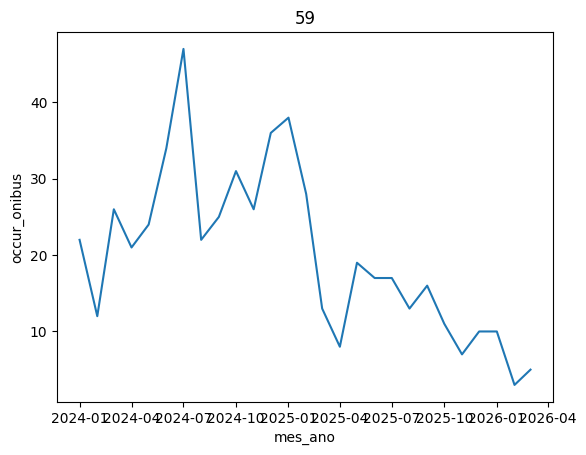

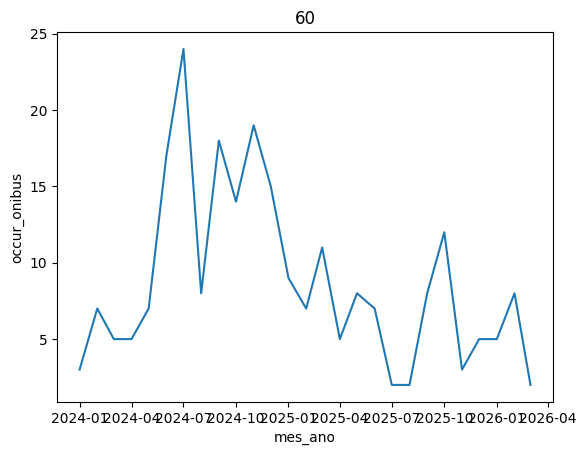

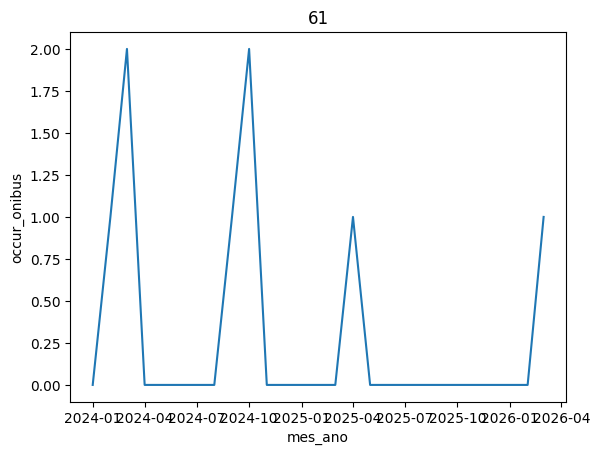

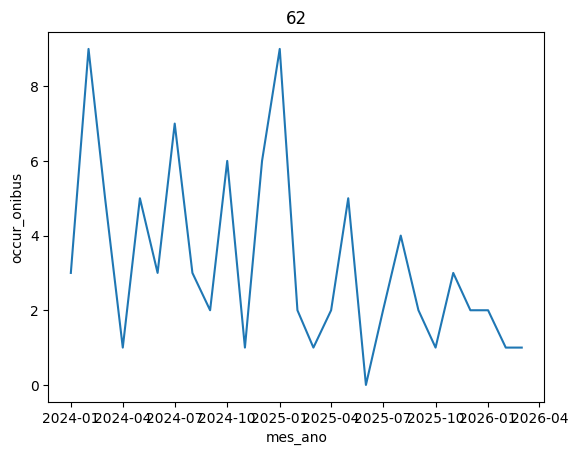

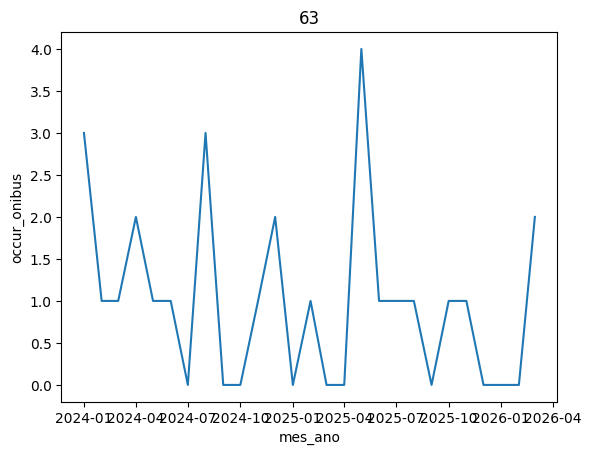

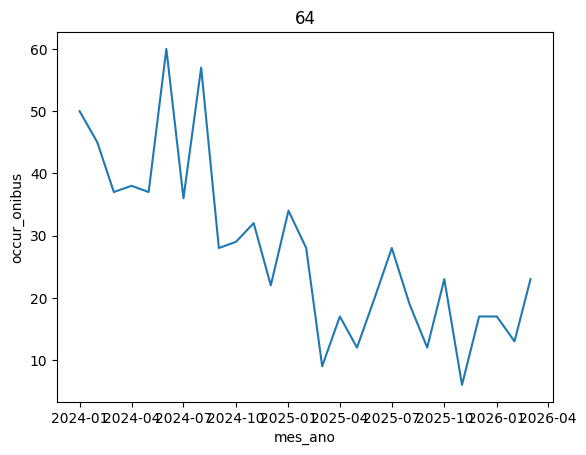

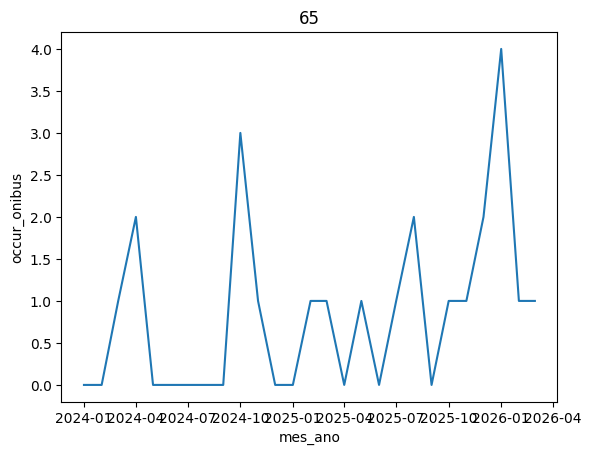

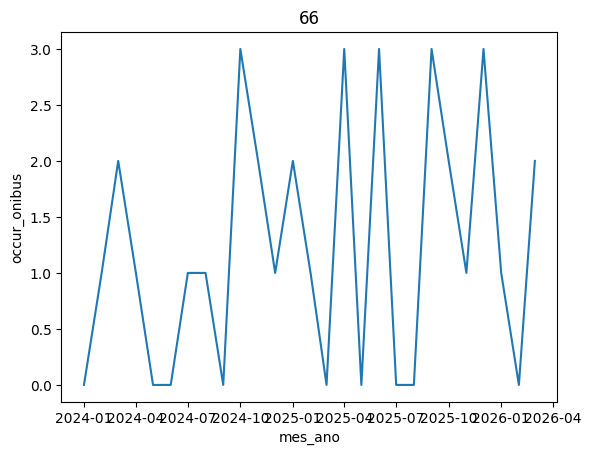

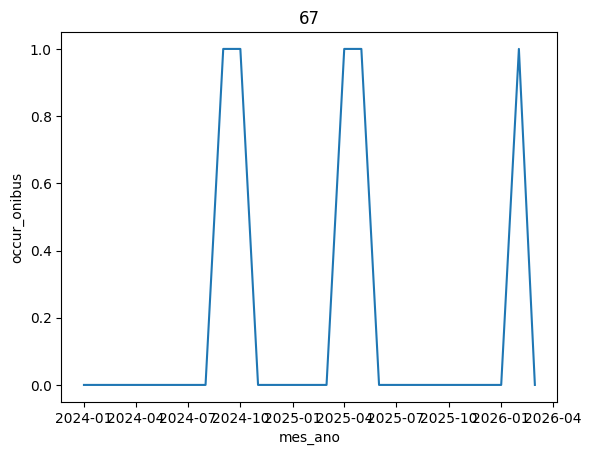

In [13]:
#e se eu pegar de 2024 pra ca?
df_rec = df[df["ano"]>=2024]
l=[]
cisps = df_rec["cisp"].unique()
for cisp in cisps:
    df_temp = df_rec[ df_rec["cisp"] == cisp]
    df_part = df_temp[["mes_ano","occur_onibus"]]
    sns.lineplot(data=df_part, x="mes_ano",y="occur_onibus")
    plt.title(cisp)
    plt.show()
    x = np.arange(len(df_part["mes_ano"]))
    coefs = np.polyfit(x, df_part["occur_onibus"], 1)
    if coefs[0] > 0:
        l.append((coefs[0],cisp))